# Composer Classification from Symbolic Music (MIDI) with Deep Learning

**LSTM · CNN · CRNN on the Kaggle *MIDI Classic Music* dataset — Bach, Beethoven, Chopin, Mozart**

**Abstract.** We build an end-to-end system that predicts the composer of a piece of classical music from its MIDI score. Pieces are converted into two complementary neural representations — onset/sustain piano-roll images and REMI event-token sequences (Huang & Yang, 2020) — and classified with three architectures: a BiLSTM with attention pooling, a CNN trained with mixup and label smoothing, and a CRNN hybrid that combines both required techniques. A classical baseline on interpretable hand-crafted features anchors the comparison. Throughout, we enforce **piece-level (grouped) train/val/test splits** so that segments of the same work never leak across splits, and we report metrics at both the segment and the piece level. Hyperparameters are tuned with Bayesian optimization (Optuna/TPE), and Grad-CAM, attention weights, and embedding projections make the models' decisions inspectable.

| Project requirement | Where it is addressed |
|---|---|
| 1. Data collection | §3 Data Acquisition & Inventory |
| 2. Data pre-processing (+ augmentation) | §4 Preprocessing & Splits, §8 Datasets & Augmentation |
| 3. Feature extraction (notes, chords, tempo) | §5 Feature Extraction, §6 Feature EDA |
| 4. Model building (LSTM + CNN) | §10–§12 Models |
| 5. Model training | §9 Training Engine, §10–§12 |
| 6. Evaluation (accuracy, precision, recall) | §7 Protocol & Baselines, §14 Final Test Evaluation |
| 7. Optimization (hyperparameter tuning) | §13 Bayesian HPO with Optuna |

## 1. Introduction & Related Work

Attributing a score to its composer is hard even for trained musicians: Bach, Beethoven, Chopin, and Mozart share a tonal vocabulary, common forms, and overlapping instrumentation, and early Beethoven is famously "Mozartean." What differs is *statistical style* — voice-leading density, harmonic rhythm, ornamentation, texture — exactly the kind of distributed, subtle signal deep networks excel at extracting.

**Related work, briefly.** Early systems used hand-crafted global descriptors (pitch-class and interval histograms) with classical ML. Later work treated piano rolls as images for CNNs, and MIDI event sequences as language for RNNs. The current research frontier tokenizes MIDI into discrete events — REMI (Huang & Yang, 2020, *Pop Music Transformer*) — and pretrains transformers on large corpora (MidiBERT-Piano, Chou et al. 2021; MusicBERT, Zeng et al. 2021). We deliberately borrow the *representations* from this line of work (REMI tokens, onset/sustain rolls) while keeping the models compact and trainable on a single GPU: for a four-class problem with a few hundred pieces per class, disciplined methodology beats parameter count.

**Design principles for this notebook.**
1. **No leakage.** Segmenting pieces into windows and splitting windows randomly puts chunks of the same composition in both train and test, inflating accuracy by 10–20 points. We split by *piece* (with near-duplicate grouping) and report segment-level and piece-level metrics separately.
2. **Complexity only where it pays.** Modern-but-cheap techniques — REMI tokenization, attention pooling, mixup, label smoothing, cosine schedules, TPE search — rather than exotic architectures.
3. **Trust, then verify.** A classical baseline quantifies what the deep models actually add; Grad-CAM, attention maps, and embeddings show *what* they learned.

## 2. Environment & Configuration

All knobs live in one `Config` dataclass — single source of truth for paths, segmentation, augmentation, and training. Set `fast_dev_run=True` for a quick smoke-test pass (small file subsample, few epochs/trials) before committing to the full run.

**Colab/Google Drive:** mount Drive first, then point `data_dir`, `cache_dir`, and `output_dir` at your project folder. Training metrics, checkpoints, configuration, and the persistent Optuna study are written beneath `output_dir / run_name`, so a Colab disconnect does not erase the run record. Change `run_name` when starting a genuinely new experiment.

In [1]:
# Colab: mount Drive before setting the paths in Config below.
from google.colab import drive
drive.mount("/content/drive")

# Colab/Kaggle already ship torch, sklearn, pandas, matplotlib, tqdm.
# We add the symbolic-music stack, dataset download, HPO, and TensorBoard logging.
%pip install -q pretty_midi "miditok>=3.0" symusic kagglehub optuna tensorboard

# Local environments (uncomment if starting from a bare venv):
# %pip install -q torch pandas scikit-learn matplotlib tqdm pretty_midi "miditok>=3.0" symusic kagglehub optuna tensorboard

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 65.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 8.4 MB/s eta 0:00:00


In [2]:
import hashlib
import json
import math
import os
import random
import re
import sys
import time
import warnings
from collections import Counter
from concurrent.futures import ProcessPoolExecutor
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pretty_midi
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning, module="miditok")
warnings.filterwarnings("ignore", category=RuntimeWarning)  # pretty_midi tempo-estimation chatter

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 160)

NOTEBOOK_T0 = time.time()
print(f"python  {sys.version.split()[0]}")
print(f"torch   {torch.__version__} | CUDA available: {torch.cuda.is_available()}")
print(f"numpy   {np.__version__} | pandas {pd.__version__}")

python  3.12.13
torch   2.11.0+cu128 | CUDA available: True
numpy   2.0.2 | pandas 2.2.2


In [3]:
@dataclass
class Config:
    # reproducibility & environment
    seed: int = 42
    # In Colab, set these to paths under /content/drive/MyDrive/... after mounting Drive.
    data_dir: Path = Path("/content/drive/MyDrive/USD Masters of AAI/AAI-511: Deep Learning/Final Project/data")
    cache_dir: Path = Path("/content/drive/MyDrive/USD Masters of AAI/AAI-511: Deep Learning/Final Project/data/cache")
    output_dir: Path = Path("/content/drive/MyDrive/USD Masters of AAI/AAI-511: Deep Learning/Final Project/training_runs")
    run_name: str = "composer_large_gpu_run"  # change for each new experiment
    num_workers: int = os.cpu_count() or 2

    # task
    composers: tuple = ("Bach", "Beethoven", "Chopin", "Mozart")

    # file-level filtering
    min_notes: int = 50          # drop near-empty / corrupt scores
    min_duration: float = 15.0   # seconds

    # piano-roll segmentation
    segment_seconds: float = 30.0
    fs: int = 10                 # roll frames per second -> T = 300
    train_hop: float = 15.0      # 50% overlap for training windows
    eval_hop: float = 30.0       # non-overlapping windows for val/test
    min_seg_notes: int = 20      # discard windows that are mostly silence

    # token segmentation (REMI)
    max_tokens: int = 512
    token_stride: int = 256      # 50% overlap for training chunks
    min_seg_tokens: int = 64

    # augmentation (train only)
    max_pitch_shift: int = 5     # semitones, both directions
    tempo_jitter: float = 0.10   # +-10% playback speed
    vel_jitter: float = 0.15     # +-15% velocity scaling
    token_transpose_p: float = 0.9

    # training
    batch_size: int = 512
    epochs: int = 50
    patience: int = 10
    lr: float = 2e-3
    weight_decay: float = 1e-4
    warmup_frac: float = 0.1
    label_smoothing: float = 0.05
    mixup_alpha: float = 0.3

    # splits (fractions of *pieces*, stratified by composer)
    val_frac: float = 0.15
    test_frac: float = 0.15

    # hyperparameter optimization
    n_trials: int = 50
    hpo_epochs: int = 12

    # development helpers
    fast_dev_run: bool = False          # subsample files + shrink budgets for a smoke test
    files_per_composer_dev: int = 30
    force_rebuild: bool = False         # ignore on-disk caches


CFG = Config()
if CFG.fast_dev_run:
    CFG.epochs, CFG.n_trials, CFG.hpo_epochs = 4, 3, 2
    print(">>> FAST_DEV_RUN: subsampled data, tiny budgets — results are NOT meaningful. <<<")

CLASSES = list(CFG.composers)
CLS2IDX = {c: i for i, c in enumerate(CLASSES)}


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True  # fixed input sizes -> let cuDNN autotune


seed_everything(CFG.seed)
USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda" if USE_CUDA else "cpu")
AMP_DTYPE = torch.bfloat16 if USE_CUDA and torch.cuda.is_bf16_supported() else torch.float16

if USE_CUDA:
    torch.set_float32_matmul_precision("high")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

RUN_DIR = CFG.output_dir / CFG.run_name
MODEL_DIR = RUN_DIR / "checkpoints"
for d in (
    CFG.data_dir,
    CFG.cache_dir,
    CFG.cache_dir / "notes",
    CFG.cache_dir / "tokens",
    RUN_DIR,
    MODEL_DIR,
):
    d.mkdir(parents=True, exist_ok=True)

config_snapshot = {
    key: str(value) if isinstance(value, Path) else value
    for key, value in asdict(CFG).items()
}
(RUN_DIR / "config.json").write_text(
    json.dumps(config_snapshot, indent=2), encoding="utf-8"
)

environment = {
    "python": sys.version.split()[0],
    "torch": torch.__version__,
    "cuda_runtime": torch.version.cuda,
    "cudnn": torch.backends.cudnn.version(),
    "device": str(DEVICE),
    "amp_dtype": str(AMP_DTYPE),
}
if USE_CUDA:
    props = torch.cuda.get_device_properties(0)
    environment.update(
        gpu_name=props.name,
        compute_capability=f"{props.major}.{props.minor}",
        gpu_memory_gib=round(props.total_memory / 1024**3, 1),
    )
(RUN_DIR / "environment.json").write_text(
    json.dumps(environment, indent=2), encoding="utf-8"
)

print(f"device: {environment.get('gpu_name', DEVICE)} | AMP: {AMP_DTYPE}")
if USE_CUDA:
    print(
        f"CUDA {torch.version.cuda} | cuDNN {torch.backends.cudnn.version()} | "
        f"capability {environment['compute_capability']} | "
        f"VRAM {environment['gpu_memory_gib']:.1f} GiB"
    )
print(f"run artifacts: {RUN_DIR}")

device: NVIDIA RTX PRO 6000 Blackwell Server Edition | AMP: torch.bfloat16
CUDA 12.8 | cuDNN 91900 | capability 12.0 | VRAM 95.0 GiB
run artifacts: /content/drive/MyDrive/USD Masters of AAI/AAI-511: Deep Learning/Final Project/training_runs/composer_large_gpu_run


## 3. Data Acquisition & Inventory — *Project Step 1*

We pull the [MIDI Classic Music dataset](https://www.kaggle.com/datasets/blanderbuss/midi-classic-music) via `kagglehub` (anonymous download works for public datasets) and keep only the four target composers. This dataset is **messy in ways that matter**: nested folders, duplicated arrangements of the same work, unreadable files, and stray pieces filed under the wrong composer. So before any modeling we build a *manifest* — one audited row per file with a content hash, parse status, duration, and note count — and every later stage keys off it.

In [4]:
import shutil

DATASET_SLUG = "blanderbuss/midi-classic-music"
RAW_ROOT = CFG.data_dir / "raw"

if not RAW_ROOT.exists():
    print("Data not found in Google Drive. Downloading via kagglehub...")
    try:
        import kagglehub
        temp_dir = Path(kagglehub.dataset_download(DATASET_SLUG))
        print(f"Downloaded to temporary cache: {temp_dir}. Moving to Drive...")
        shutil.copytree(temp_dir, RAW_ROOT)
        print("Successfully saved to:", RAW_ROOT)
    except Exception as e:
        print(f"kagglehub download failed ({type(e).__name__}: {e}).")
        print("Manual fallback: download the zip from")
        print("  https://www.kaggle.com/datasets/blanderbuss/midi-classic-music")
        print("unzip it into", RAW_ROOT, "and re-run this cell.")
else:
    print("Dataset already exists in Google Drive at:", RAW_ROOT)

assert RAW_ROOT.exists(), "Dataset not available — see instructions above."

Data not found in Google Drive. Downloading via kagglehub...


100%|██████████| 68.2M/68.2M [00:00<00:00, 128MB/s]

Extracting files...


Downloaded to temporary cache: /root/.cache/kagglehub/datasets/blanderbuss/midi-classic-music/versions/1. Moving to Drive...
Successfully saved to: /content/drive/MyDrive/USD Masters of AAI/AAI-511: Deep Learning/Final Project/data/raw


In [5]:
def find_midi_files(root: Path, composers) -> tuple[dict, pd.DataFrame]:
    """Locate composer directories (case-insensitive, any nesting depth) and list their MIDI files."""
    dirs = {c: [] for c in composers}
    for d in root.rglob("*"):
        if d.is_dir():
            for c in composers:
                if d.name.strip().lower() == c.lower():
                    dirs[c].append(d)
    rows, seen = [], set()
    for c, dlist in dirs.items():
        for d in dlist:
            for f in d.rglob("*"):
                if f.is_file() and f.suffix.lower() in {".mid", ".midi"}:
                    rp = str(f.resolve())
                    if rp not in seen:
                        seen.add(rp)
                        rows.append({"composer": c, "path": str(f)})
    return dirs, pd.DataFrame(rows)


DIRS, FILES = find_midi_files(RAW_ROOT, CLASSES)
for c in CLASSES:
    print(f"{c:<10} dirs: {len(DIRS[c])}  files: {int((FILES['composer'] == c).sum()) if len(FILES) else 0}")

if len(FILES) == 0 or FILES["composer"].nunique() < len(CLASSES):
    print("\nCould not find all composer folders. Top-level directories present:")
    print(sorted({p.name for p in RAW_ROOT.rglob("*") if p.is_dir()})[:60])
assert len(FILES) > 0, "No MIDI files found — check the dataset layout above."

Bach       dirs: 1  files: 1024
Beethoven  dirs: 1  files: 213
Chopin     dirs: 1  files: 136
Mozart     dirs: 1  files: 257


In [11]:
def inspect_midi(path_str: str) -> dict:
    """Worker: hash + parse one MIDI file, returning an audit record (never raises)."""
    import hashlib
    import warnings
    from pathlib import Path

    import pretty_midi

    p = Path(path_str)
    rec = {"path": path_str, "md5": None, "valid": False, "n_notes": 0,
           "duration": 0.0, "n_instruments": 0, "error": ""}
    try:
        rec["md5"] = hashlib.md5(p.read_bytes()).hexdigest()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            pm = pretty_midi.PrettyMIDI(str(p))
        rec.update(
            valid=True,
            n_notes=int(sum(len(i.notes) for i in pm.instruments if not i.is_drum)),
            duration=float(pm.get_end_time()),
            n_instruments=len(pm.instruments),
        )
    except Exception as e:
        rec["error"] = f"{type(e).__name__}: {str(e)[:100]}"
    return rec


MANIFEST_PATH = CFG.cache_dir / "manifest.csv"
if MANIFEST_PATH.exists() and not CFG.force_rebuild:
    manifest = pd.read_csv(MANIFEST_PATH)

    # Update absolute paths to match the current environment's RAW_ROOT
    if "relpath" in manifest.columns:
        manifest["path"] = manifest["relpath"].apply(lambda r: str(RAW_ROOT / r))
        manifest.to_csv(MANIFEST_PATH, index=False)  # Save the updated paths back to the cache

    print(f"Loaded cached manifest: {len(manifest)} files (paths updated for current environment)")
else:
    paths = FILES["path"].tolist()
    try:  # ProcessPool works on Linux/Colab (fork); falls back to serial elsewhere
        with ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
            records = list(tqdm(ex.map(inspect_midi, paths, chunksize=16),
                                total=len(paths), desc="Parsing MIDI"))
    except Exception:
        records = [inspect_midi(p) for p in tqdm(paths, desc="Parsing MIDI (serial)")]
    manifest = pd.DataFrame(records)
    manifest["composer"] = FILES["composer"].values

    n_invalid = int((~manifest["valid"]).sum())
    keep = manifest["valid"] & (manifest["n_notes"] >= CFG.min_notes) & (manifest["duration"] >= CFG.min_duration)
    print(f"Dropped {n_invalid} unparseable and {int((~keep).sum()) - n_invalid} too-short/sparse files.")
    manifest = manifest[keep].reset_index(drop=True)

    manifest["relpath"] = manifest["path"].map(lambda p: str(Path(p).relative_to(RAW_ROOT)))
    manifest["file_id"] = manifest["relpath"].map(lambda r: hashlib.md5(r.encode()).hexdigest()[:12])
    manifest["y"] = manifest["composer"].map(CLS2IDX)
    manifest.to_csv(MANIFEST_PATH, index=False)

if CFG.fast_dev_run:
    manifest = (manifest.groupby("composer", group_keys=False)
                        .apply(lambda g: g.sample(min(len(g), CFG.files_per_composer_dev),
                                                  random_state=CFG.seed))
                        .reset_index(drop=True))
    print(f"FAST_DEV_RUN subsample -> {len(manifest)} files")

print(f"\nUsable files: {len(manifest)}")
display(manifest.groupby("composer")[["n_notes", "duration"]].agg(["count", "median"]).round(1))

Loaded cached manifest: 1628 files (paths updated for current environment)

Usable files: 1628


n_notes         duration       
            count  median    count median
composer                                 
Bach         1024   617.5     1024   76.8
Beethoven     212  4749.0      212  397.4
Chopin        136  1604.5      136  157.5
Mozart        256  4675.0      256  347.8

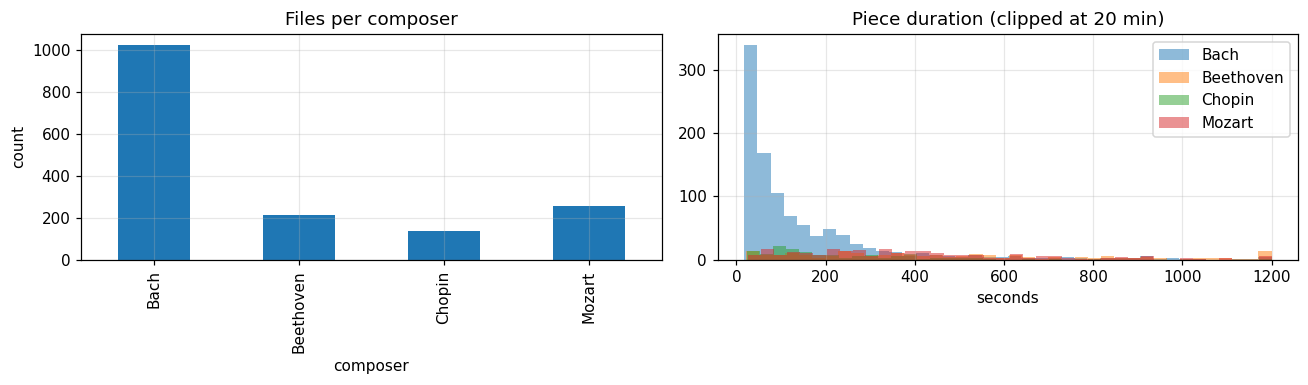

Class imbalance is real (Bach dominates) — we will handle it with balanced
sampling during training and macro-averaged metrics during evaluation.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
manifest["composer"].value_counts().reindex(CLASSES).plot.bar(ax=axes[0], color="tab:blue")
axes[0].set(title="Files per composer", ylabel="count")
for c in CLASSES:
    axes[1].hist(manifest.loc[manifest["composer"] == c, "duration"].clip(upper=1200),
                 bins=40, alpha=0.5, label=c)
axes[1].set(title="Piece duration (clipped at 20 min)", xlabel="seconds")
axes[1].legend()
plt.tight_layout()
plt.show()

print("Class imbalance is real (Bach dominates) — we will handle it with balanced")
print("sampling during training and macro-averaged metrics during evaluation.")

## 4. Preprocessing: Deduplication & Leakage-Safe Splits — *Project Step 2*

Two silent failure modes get fixed here:

1. **Exact duplicates.** The archive contains byte-identical files under different names; we collapse them by content hash (MD5).
2. **Near-duplicates & segment leakage.** The same work often appears as `sonata_no5.mid` and `Sonata No.5 (1).mid`. If any two renditions of a work — or two 30-second windows of the *same* file — straddle the train/test boundary, the model is graded on memorization. We therefore assign every file a normalized `piece_key` (composer + alphanumeric-only filename stem) and split **at the piece-key level**, stratified by composer. Every window and token chunk inherits its piece's split; nothing crosses over.

Augmentation (pitch transposition, tempo scaling, velocity jitter) is defined in §5 and applied **on-the-fly to training data only** in §8, so validation and test stay clean.

In [15]:
before = len(manifest)
manifest = manifest.sort_values("relpath").drop_duplicates(subset="md5", keep="first").reset_index(drop=True)
print(f"Exact duplicates removed by content hash: {before - len(manifest)}")


def normalize_stem(path_str: str) -> str:
    return re.sub(r"[^a-z0-9]", "", Path(path_str).stem.lower())


manifest["piece_key"] = manifest["composer"] + "::" + manifest["relpath"].map(normalize_stem)
multi = manifest["piece_key"].value_counts()
print(f"Files: {len(manifest)} | distinct piece groups: {manifest['piece_key'].nunique()} "
      f"| groups holding >1 file (near-duplicates kept on same side of split): {int((multi > 1).sum())}")

Exact duplicates removed by content hash: 20
Files: 1608 | distinct piece groups: 1608 | groups holding >1 file (near-duplicates kept on same side of split): 0


In [16]:
def grouped_stratified_split(df: pd.DataFrame, val_frac: float, test_frac: float, seed: int) -> pd.Series:
    """Assign train/val/test at the piece-group level, stratified by composer."""
    groups = df.groupby("piece_key")["composer"].first().reset_index()
    trval, te = train_test_split(groups, test_size=test_frac,
                                 stratify=groups["composer"], random_state=seed)
    tr, va = train_test_split(trval, test_size=val_frac / (1.0 - test_frac),
                              stratify=trval["composer"], random_state=seed)
    mapping = {k: "train" for k in tr["piece_key"]}
    mapping.update({k: "val" for k in va["piece_key"]})
    mapping.update({k: "test" for k in te["piece_key"]})
    return df["piece_key"].map(mapping)


manifest["split"] = grouped_stratified_split(manifest, CFG.val_frac, CFG.test_frac, CFG.seed)

# hard guarantee: no piece group appears in more than one split
overlap = manifest.groupby("piece_key")["split"].nunique()
assert (overlap == 1).all(), "LEAKAGE: a piece group crosses splits!"
print("Leakage check passed: every piece group lives in exactly one split.\n")
display(pd.crosstab(manifest["composer"], manifest["split"], margins=True))

Leakage check passed: every piece group lives in exactly one split.



split,test,train,val,All
composer,,,,
Bach,153,708,153,1014
Beethoven,31,146,31,208
Chopin,20,92,20,132
Mozart,38,178,38,254
All,242,1124,242,1608


## 5. Feature Extraction — *Project Step 3*

Each piece is converted into **three complementary representations**, each cached to disk so re-runs are fast and deterministic:

| Representation | Consumed by | What it captures |
|---|---|---|
| **Onset + sustain piano roll** (2×88×300 tensor, 30 s @ 10 Hz) | CNN, CRNN | Texture, harmony, register — the "image" of the music. The separate onset channel preserves articulation that a plain roll destroys. |
| **REMI token sequence** (Huang & Yang 2020, via `miditok`) | BiLSTM | Music as language: bar/position/tempo/pitch/velocity/duration events — notes and tempo in sequential form; simultaneous notes remain visible as co-onsets. |
| **Hand-crafted global descriptors** (45 features: pitch-class, melodic-interval, and explicit major/minor/diminished/augmented triad-quality histograms; note density, polyphony, tempo, and velocity statistics) | Classical baseline | Interpretable whole-piece summary statistics; the explicit chord features satisfy the notes/chords/tempo requirement without changing or retraining the REMI branch. |

Chord qualities are detected from pitch-class sets whose onsets fall within 50 ms, then normalized into a transposition-invariant four-bin histogram. `use_chords=False` remains deliberate for REMI so the existing LSTM vocabulary and checkpoint stay valid.

Augmentations operate at the *note-event level* (exact pitch transposition ±5 semitones, ±10% tempo, ±15% velocity) rather than as image-space hacks, and token transposition is done with an O(n) vocabulary remap — no re-tokenization needed.

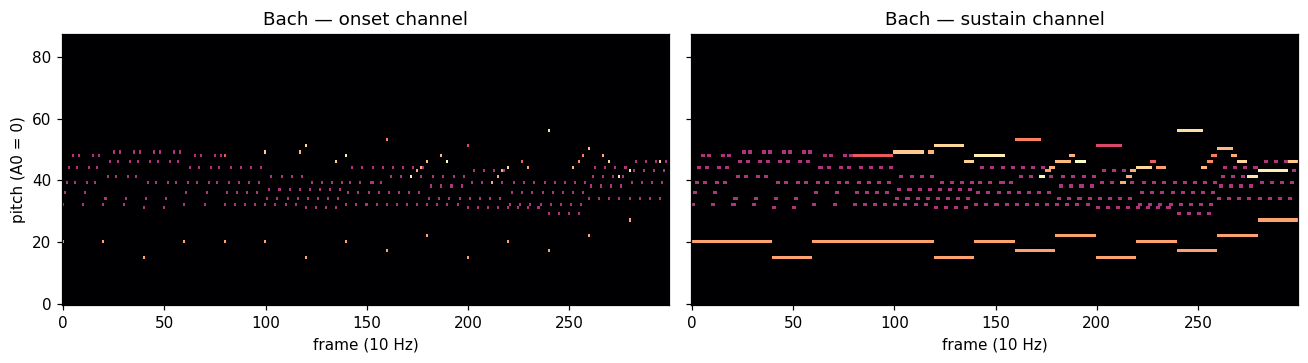

Roll tensor shape: (2, 88, 300) | onsets: 284


In [17]:
# --- Core representation functions (shared by all models) -----------------
N_PITCH, PITCH_MIN = 88, 21  # piano range A0 (21) .. C8 (108)


def extract_note_arrays(pm):
    """Flatten a PrettyMIDI object into compact, sorted numpy note arrays.

    Returns a dict with float32 start/end (seconds), int16 pitch,
    uint8 velocity and a scalar tempo estimate — or None if the file
    contains no pitched notes.
    """
    starts, ends, pitches, vels = [], [], [], []
    for inst in pm.instruments:
        if inst.is_drum:
            continue
        for n in inst.notes:
            starts.append(n.start)
            ends.append(n.end)
            pitches.append(n.pitch)
            vels.append(n.velocity)
    if not starts:
        return None
    order = np.argsort(np.asarray(starts, dtype=np.float64), kind="stable")
    try:
        tempo = float(pm.estimate_tempo())
    except Exception:
        tempo = 120.0
    return {
        "start": np.asarray(starts, dtype=np.float32)[order],
        "end": np.asarray(ends, dtype=np.float32)[order],
        "pitch": np.asarray(pitches, dtype=np.int16)[order],
        "velocity": np.asarray(vels, dtype=np.uint8)[order],
        "tempo": tempo,
    }


def render_roll(nd, t0, seg_seconds, fs, pitch_shift=0, tempo_factor=1.0, vel_factor=1.0):
    """Render a (2, 88, T) onset+sustain piano-roll for the window starting at t0.

    Channel 0 marks note onsets, channel 1 the full sustained duration —
    a representation borrowed from the transcription literature that keeps
    articulation information a plain piano-roll destroys. Augmentations
    (pitch shift in semitones, tempo/velocity scaling) are applied at the
    note-event level, so they are exact rather than image-space hacks.
    """
    T = int(round(seg_seconds * fs))
    roll = np.zeros((2, N_PITCH, T), dtype=np.float32)
    span = seg_seconds * tempo_factor  # tempo_factor > 1 = play faster => window covers more source time
    sel = (nd["end"] > t0) & (nd["start"] < t0 + span)
    if not np.any(sel):
        return roll
    s = (nd["start"][sel] - t0) / tempo_factor
    e = (nd["end"][sel] - t0) / tempo_factor
    p = nd["pitch"][sel].astype(np.int32) + int(pitch_shift)
    v = np.clip(nd["velocity"][sel].astype(np.float32) * vel_factor, 1.0, 127.0) / 127.0
    ok = (p >= PITCH_MIN) & (p < PITCH_MIN + N_PITCH)
    s, e, p, v = s[ok], e[ok], p[ok] - PITCH_MIN, v[ok]
    fi = np.floor(s * fs).astype(np.int64)
    fj = np.clip(np.ceil(e * fs).astype(np.int64), 1, T)
    onset = (fi >= 0) & (fi < T)  # onset must fall inside the window
    roll[0, p[onset], fi[onset]] = v[onset]
    for a, b, pp, vv in zip(np.maximum(fi, 0), fj, p, v):
        if a < b:
            seg = roll[1, pp, a:b]
            np.maximum(seg, vv, out=seg)
    return roll


def tokenize_midi(tokenizer, path):
    """Tokenize one MIDI file into a flat int32 id array (None on failure).

    miditok can return either a single TokSequence (one-token-stream
    tokenizers) or a list of per-track sequences; we normalise both cases.
    """
    try:
        res = tokenizer(Path(path))
        if isinstance(res, list):
            ids = [t for seq in res for t in seq.ids]
        else:
            ids = res.ids
        ids = np.asarray(ids, dtype=np.int32)
        return ids if ids.size > 0 else None
    except Exception:
        return None


def build_transpose_maps(tokenizer, max_shift=5):
    """Vocabulary-level pitch transposition tables for token augmentation.

    For each shift k, returns an id->id array that maps every Pitch_p token
    to Pitch_{p+k} (identity where the target pitch is out of vocabulary,
    and for all non-pitch tokens). Applying `maps[k][ids]` transposes a
    token sequence in O(n) without re-tokenizing the MIDI.
    """
    pitch_re = re.compile(r"^Pitch_(\d+)$")
    vocab_size = len(tokenizer)
    pitch_tokens = {}
    for tok, tid in tokenizer.vocab.items():
        m = pitch_re.match(tok)
        if m:
            pitch_tokens[int(m.group(1))] = tid
    maps = {}
    for k in range(-max_shift, max_shift + 1):
        mp = np.arange(vocab_size, dtype=np.int64)
        for pval, tid in pitch_tokens.items():
            if (pval + k) in pitch_tokens:
                mp[tid] = pitch_tokens[pval + k]
        maps[k] = mp
    return maps


def triad_quality_histogram(
    starts: np.ndarray,
    pitches: np.ndarray,
    onset_tolerance: float = 0.05,
) -> dict[str, float]:
    """Return normalized major/minor/diminished/augmented triad counts.

    Notes quantized to the same onset-tolerance bin form one pitch-class set.
    Every matching root-quality template is counted, including valid triads
    embedded in seventh or added-note chords. The result is transposition
    invariant and all zeros when no triad is observed.

    Args:
        starts: Note onset times in seconds.
        pitches: MIDI pitch numbers aligned with ``starts``.
        onset_tolerance: Maximum onset quantization width in seconds.

    Returns:
        Four normalized chord-quality features whose sum is one when at
        least one triad is detected.
    """
    if starts.size != pitches.size:
        raise ValueError("starts and pitches must contain the same number of notes")
    if onset_tolerance <= 0:
        raise ValueError("onset_tolerance must be positive")

    templates: dict[str, frozenset[int]] = {
        "major": frozenset((0, 4, 7)),
        "minor": frozenset((0, 3, 7)),
        "diminished": frozenset((0, 3, 6)),
        "augmented": frozenset((0, 4, 8)),
    }
    counts: dict[str, int] = {quality: 0 for quality in templates}
    if starts.size == 0:
        return {f"chord_{quality}_frac": 0.0 for quality in templates}

    onset_bins = np.rint((starts - starts.min()) / onset_tolerance).astype(np.int64)
    order = np.argsort(onset_bins, kind="stable")
    sorted_bins = onset_bins[order]
    sorted_pitch_classes = pitches[order].astype(np.int64) % 12
    split_points = np.flatnonzero(np.diff(sorted_bins)) + 1

    for onset_group in np.split(sorted_pitch_classes, split_points):
        pitch_classes = frozenset(int(pc) for pc in onset_group)
        if len(pitch_classes) < 3:
            continue
        for root in pitch_classes:
            relative_intervals = frozenset((pc - root) % 12 for pc in pitch_classes)
            for quality, template in templates.items():
                if template.issubset(relative_intervals):
                    counts[quality] += 1

    total = float(sum(counts.values()))
    return {
        f"chord_{quality}_frac": count / total if total else 0.0
        for quality, count in counts.items()
    }


def hand_features(nd):
    """Return 45 interpretable whole-piece descriptors for classical baselines."""
    s, e, p, v = nd["start"], nd["end"], nd["pitch"].astype(np.int64), nd["velocity"].astype(np.float32)
    dur = float(max(e.max() - s.min(), 1e-6))
    f = {
        "n_notes": float(len(p)),
        "duration": dur,
        "note_density": len(p) / dur,
        "pitch_mean": float(p.mean()),
        "pitch_std": float(p.std()),
        "pitch_min": float(p.min()),
        "pitch_max": float(p.max()),
        "pitch_range": float(p.max() - p.min()),
        "vel_mean": float(v.mean()),
        "vel_std": float(v.std()),
        "note_len_mean": float((e - s).mean()),
        "note_len_std": float((e - s).std()),
        "tempo_est": float(nd.get("tempo", 120.0)),
    }
    pc = np.bincount(p % 12, minlength=12).astype(np.float64)
    pc /= max(pc.sum(), 1.0)
    for i in range(12):
        f[f"pc_{i}"] = pc[i]
    if len(p) > 1:  # melodic interval profile (successive onsets)
        iv = np.clip(np.abs(np.diff(p)), 0, 12)
        ih = np.bincount(iv, minlength=13).astype(np.float64)
        ih /= max(ih.sum(), 1.0)
    else:
        ih = np.zeros(13)
    for i in range(13):
        f[f"int_{i}"] = ih[i]
    # polyphony / texture on a 10 Hz grid via sorted event counting
    grid = np.arange(s.min(), e.max(), 0.1)
    if len(grid) > 0:
        active = np.searchsorted(np.sort(s), grid, side="right") - np.searchsorted(np.sort(e), grid, side="right")
        f["poly_mean"] = float(active.mean())
        f["poly_max"] = float(active.max())
        f["silence_frac"] = float((active == 0).mean())
    else:
        f["poly_mean"] = f["poly_max"] = 1.0
        f["silence_frac"] = 0.0
    f.update(triad_quality_histogram(s, p))
    return f


# --- Visual sanity check on a real file --------------------------------------
_demo = manifest.iloc[0]
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    _pm = pretty_midi.PrettyMIDI(str(_demo["path"]))
_nd = extract_note_arrays(_pm)
_roll = render_roll(_nd, 0.0, CFG.segment_seconds, CFG.fs)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)
for ax, ch, name in zip(axes, _roll, ["onset channel", "sustain channel"]):
    ax.imshow(ch, aspect="auto", origin="lower", cmap="magma", interpolation="nearest")
    ax.set(title=f"{_demo['composer']} — {name}", xlabel=f"frame ({CFG.fs} Hz)")
    ax.grid(False)
axes[0].set_ylabel("pitch (A0 = 0)")
plt.tight_layout()
plt.show()
print(f"Roll tensor shape: {_roll.shape} | onsets: {int((_roll[0] > 0).sum())}")

In [18]:
NOTES_DIR = CFG.cache_dir / "notes"


def notes_job(args) -> tuple:
    """Worker: parse one file into compact note arrays and cache as .npz."""
    fid, path = args
    out = NOTES_DIR / f"{fid}.npz"
    if out.exists():
        return fid, True
    import warnings

    import numpy as np
    import pretty_midi
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            pm = pretty_midi.PrettyMIDI(str(path))
        nd = extract_note_arrays(pm)
        if nd is None:
            return fid, False
        np.savez_compressed(out, **nd)
        return fid, True
    except Exception:
        return fid, False


jobs = list(zip(manifest["file_id"], manifest["path"]))
try:
    with ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
        results = list(tqdm(ex.map(notes_job, jobs, chunksize=16),
                            total=len(jobs), desc="Caching note arrays"))
except Exception:
    results = [notes_job(j) for j in tqdm(jobs, desc="Caching note arrays (serial)")]

ok_ids = {fid for fid, ok in results if ok}
NOTES = {}
for fid in tqdm(sorted(ok_ids), desc="Loading note cache"):
    with np.load(NOTES_DIR / f"{fid}.npz") as z:
        NOTES[fid] = {"start": z["start"], "end": z["end"], "pitch": z["pitch"],
                      "velocity": z["velocity"], "tempo": float(z["tempo"])}

dropped = len(manifest) - len(ok_ids)
manifest = manifest[manifest["file_id"].isin(NOTES)].reset_index(drop=True)
print(f"Note arrays in memory for {len(NOTES)} files ({dropped} dropped at this stage).")

Caching note arrays:   0%|          | 0/1608 [00:00<?, ?it/s]

Loading note cache:   0%|          | 0/1608 [00:00<?, ?it/s]

Note arrays in memory for 1608 files (0 dropped at this stage).


In [19]:
def make_roll_segments(df: pd.DataFrame, notes: dict) -> pd.DataFrame:
    """Slice each piece into 30 s windows: 50% overlap for train, disjoint for val/test."""
    rows = []
    for r in df.itertuples():
        nd = notes[r.file_id]
        dur = float(nd["end"].max())
        hop = CFG.train_hop if r.split == "train" else CFG.eval_hop
        starts = np.arange(0.0, max(dur - CFG.segment_seconds, 0.0) + 1e-6, hop)
        if len(starts) == 0:
            starts = np.array([0.0])
        onsets = nd["start"]
        for t0 in starts:
            n_on = int(((onsets >= t0) & (onsets < t0 + CFG.segment_seconds)).sum())
            if n_on >= CFG.min_seg_notes or (len(starts) == 1 and n_on >= 10):
                rows.append((r.file_id, float(t0), int(r.y), r.split))
    return pd.DataFrame(rows, columns=["file_id", "t0", "y", "split"])


ROLL_SEGS = make_roll_segments(manifest, NOTES)
print(f"Piano-roll segments: {len(ROLL_SEGS)}")
display(pd.crosstab(ROLL_SEGS["y"].map(dict(enumerate(CLASSES))), ROLL_SEGS["split"], margins=True))

Piano-roll segments: 20365


split,test,train,val,All
y,,,,
Bach,678,6570,665,7913
Beethoven,544,4374,537,5455
Chopin,102,1288,137,1527
Mozart,495,4493,482,5470
All,1819,16725,1821,20365


In [20]:
from miditok import REMI, TokenizerConfig

TOK_CONFIG = TokenizerConfig(
    pitch_range=(21, 109),
    num_velocities=16,
    use_programs=True,
    one_token_stream_for_programs=True,   # one flat event stream per file
    use_tempos=True,                      # tempo events kept -> Step 3's "tempo"
    use_time_signatures=False,
    use_chords=False,                     # preserve trained vocabulary; explicit chord features are in hand_features
)
TOKENIZER = REMI(TOK_CONFIG)
VOCAB_SIZE = len(TOKENIZER)
PAD_ID = int(getattr(TOKENIZER, "pad_token_id", TOKENIZER.vocab.get("PAD_None", 0)))
INV_VOCAB = {v: k for k, v in TOKENIZER.vocab.items()}
print(f"REMI vocabulary: {VOCAB_SIZE} tokens | PAD id: {PAD_ID}")

TOKEN_DIR = CFG.cache_dir / "tokens"
TOKEN_IDS, n_fail = {}, 0
for r in tqdm(list(manifest.itertuples()), desc="Tokenizing (REMI)"):
    fp = TOKEN_DIR / f"{r.file_id}.npz"
    if fp.exists() and not CFG.force_rebuild:
        with np.load(fp) as z:
            TOKEN_IDS[r.file_id] = z["ids"]
        continue
    ids = tokenize_midi(TOKENIZER, r.path)
    if ids is None:
        n_fail += 1
        continue
    np.savez_compressed(fp, ids=ids)
    TOKEN_IDS[r.file_id] = ids
print(f"Tokenized {len(TOKEN_IDS)} files ({n_fail} failures) | "
      f"median length: {int(np.median([len(v) for v in TOKEN_IDS.values()]))} tokens")

TRANSPOSE = build_transpose_maps(TOKENIZER, CFG.max_pitch_shift)


def make_token_segments(df: pd.DataFrame, token_ids: dict) -> pd.DataFrame:
    """Chunk each token stream: 50% overlapping windows for train, disjoint for val/test."""
    rows = []
    for r in df.itertuples():
        ids = token_ids.get(r.file_id)
        if ids is None or len(ids) < CFG.min_seg_tokens:
            continue
        n = len(ids)
        stride = CFG.token_stride if r.split == "train" else CFG.max_tokens
        for st in range(0, max(n - CFG.max_tokens, 0) + 1, stride):
            ln = min(CFG.max_tokens, n - st)
            if ln >= CFG.min_seg_tokens or n <= CFG.max_tokens:
                rows.append((r.file_id, st, ln, int(r.y), r.split))
    return pd.DataFrame(rows, columns=["file_id", "start", "length", "y", "split"])


TOKEN_SEGS = make_token_segments(manifest, TOKEN_IDS)
print(f"\nToken segments: {len(TOKEN_SEGS)}")
display(pd.crosstab(TOKEN_SEGS["y"].map(dict(enumerate(CLASSES))), TOKEN_SEGS["split"], margins=True))

REMI vocabulary: 429 tokens | PAD id: 0


Tokenizing (REMI):   0%|          | 0/1608 [00:00<?, ?it/s]

Tokenized 1608 files (0 failures) | median length: 5561 tokens

Token segments: 72617


split,test,train,val,All
y,,,,
Bach,2257,20564,2124,24945
Beethoven,2178,18039,2573,22790
Chopin,276,4119,463,4858
Mozart,1798,16432,1794,20024
All,6509,59154,6954,72617


In [21]:
rows = []
for fid in tqdm(manifest["file_id"], desc="Hand-crafted features"):
    f = hand_features(NOTES[fid])
    f["file_id"] = fid
    rows.append(f)

FEATS_DF = pd.DataFrame(rows).merge(
    manifest[["file_id", "composer", "split", "y"]], on="file_id", validate="1:1"
)
FEAT_COLS = [c for c in FEATS_DF.columns if c not in ("file_id", "composer", "split", "y")]
CHORD_COLS = [
    "chord_major_frac",
    "chord_minor_frac",
    "chord_diminished_frac",
    "chord_augmented_frac",
]
missing_chord_cols = set(CHORD_COLS).difference(FEAT_COLS)
assert not missing_chord_cols, f"Missing explicit chord features: {sorted(missing_chord_cols)}"
print(
    f"Feature matrix: {FEATS_DF.shape[0]} pieces x {len(FEAT_COLS)} features | "
    f"explicit chord columns: {', '.join(CHORD_COLS)}"
)
display(
    FEATS_DF.groupby("composer")[
        ["note_density", "poly_mean", "pitch_range", "tempo_est", *CHORD_COLS]
    ].median().round(3)
)

Hand-crafted features:   0%|          | 0/1608 [00:00<?, ?it/s]

Feature matrix: 1608 pieces x 41 features


,note_density,poly_mean,pitch_range,tempo_est
composer,,,,
Bach,7.62,4.00,43.5,174.37
Beethoven,10.58,3.01,61.0,197.85
Chopin,11.16,2.92,66.0,194.53
Mozart,10.43,4.30,58.0,201.28


## 6. Exploratory Feature Analysis

Before modeling, we verify the representations actually carry composer signal. The piano rolls make texture differences visible to the eye (Bach's continuous contrapuntal weave vs. Chopin's melody-over-arpeggio figuration); the pitch-class profiles and polyphony/density distributions show separable — but overlapping — statistical fingerprints, which is exactly why a learned model is needed.

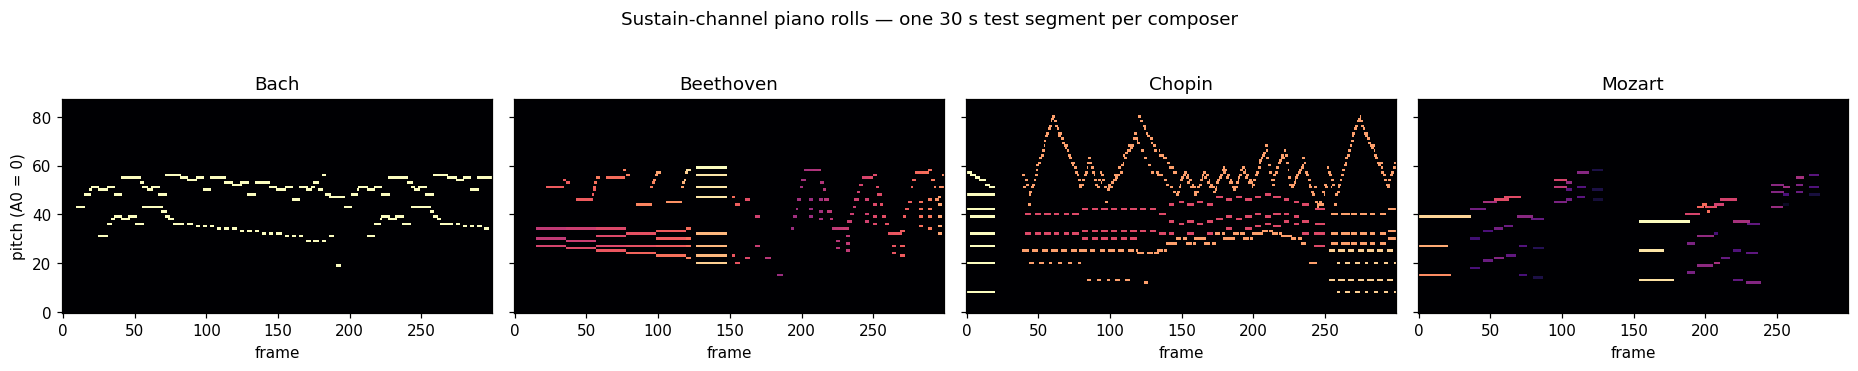

In [22]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(17, 3.2), sharey=True)
test_pool = ROLL_SEGS[ROLL_SEGS["split"] == "test"]
for ax, (ci, cname) in zip(axes, enumerate(CLASSES)):
    seg = test_pool[test_pool["y"] == ci].iloc[0]
    roll = render_roll(NOTES[seg["file_id"]], float(seg["t0"]), CFG.segment_seconds, CFG.fs)
    ax.imshow(roll[1], aspect="auto", origin="lower", cmap="magma", interpolation="nearest")
    ax.set(title=cname, xlabel="frame")
    ax.grid(False)
axes[0].set_ylabel("pitch (A0 = 0)")
fig.suptitle("Sustain-channel piano rolls — one 30 s test segment per composer", y=1.04)
plt.tight_layout()
plt.show()

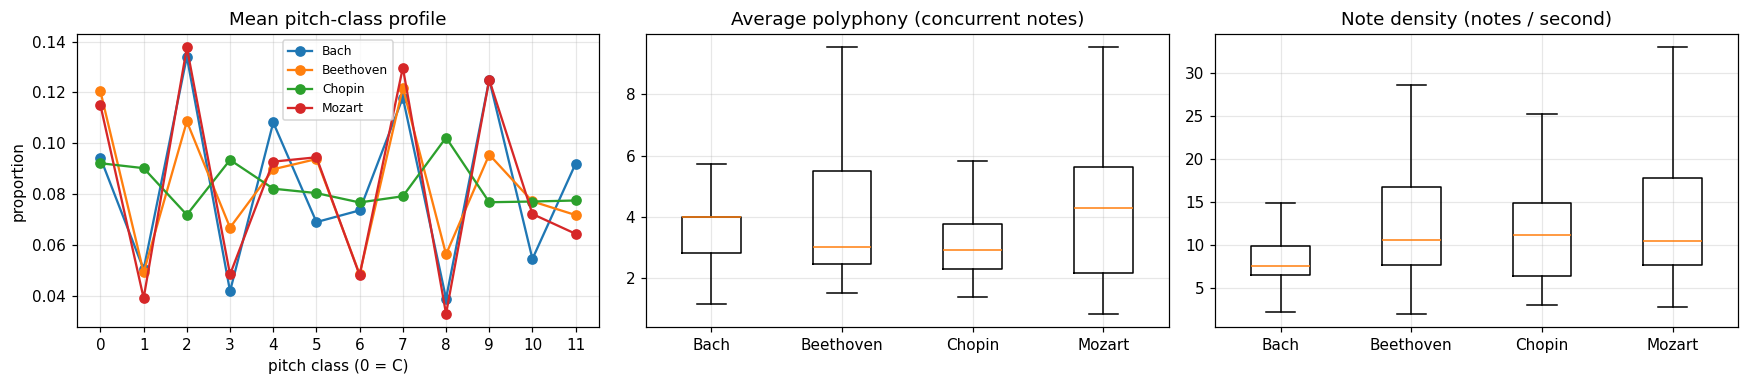

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))

pc_cols = [f"pc_{i}" for i in range(12)]
for c in CLASSES:
    axes[0].plot(range(12), FEATS_DF.loc[FEATS_DF["composer"] == c, pc_cols].mean(),
                 marker="o", label=c)
axes[0].set(title="Mean pitch-class profile", xlabel="pitch class (0 = C)", ylabel="proportion")
axes[0].set_xticks(range(12))
axes[0].legend(fontsize=8)

for ax, col, title in [(axes[1], "poly_mean", "Average polyphony (concurrent notes)"),
                       (axes[2], "note_density", "Note density (notes / second)")]:
    data = [FEATS_DF.loc[FEATS_DF["composer"] == c, col].clip(upper=FEATS_DF[col].quantile(0.98))
            for c in CLASSES]
    ax.boxplot(data, showfliers=False)
    ax.set_xticks(range(1, len(CLASSES) + 1), CLASSES)
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 7. Evaluation Protocol & Classical Baselines — *Project Step 6 (metrics defined up front)*

Metrics are fixed **before** any deep model is trained, and every model reports through the same utilities:

- **Accuracy, macro precision, macro recall, macro F1** (macro = every composer counts equally despite Bach's over-representation).
- **Two granularities.** *Segment-level*: how well single 30 s windows / 512-token chunks are classified. *Piece-level*: segment probabilities are averaged per piece and the piece gets one prediction — the number that answers the actual question, "who wrote this piece?"
- **Test discipline.** Everything up to §13 uses train/val only. The test set is evaluated exactly once, in §14, after all architectures and hyperparameters are frozen.

The classical baselines (logistic regression and gradient-boosted trees on the hand-crafted descriptors) establish the bar the deep models must clear to justify their cost.

In [24]:
def compute_metrics(y_true, y_pred) -> dict:
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {"accuracy": accuracy_score(y_true, y_pred),
            "precision": p, "recall": r, "f1": f1, "n": len(y_true)}


RESULTS = []


def log_result(model: str, split: str, level: str, m: dict) -> None:
    RESULTS.append({"model": model, "split": split, "level": level, **m})
    print(f"  {model:<22} [{split}/{level:<7}] "
          f"acc {m['accuracy']:.3f} | prec {m['precision']:.3f} | "
          f"rec {m['recall']:.3f} | F1 {m['f1']:.3f} | n={m['n']}")


def results_table() -> pd.DataFrame:
    df = pd.DataFrame(RESULTS)
    return (df.pivot_table(index="model", columns=["split", "level"], values="f1")
              .round(3).sort_index(axis=1))


def aggregate_pieces(probs: np.ndarray, ys: np.ndarray, piece_idx: np.ndarray) -> pd.DataFrame:
    """Mean segment probabilities per piece -> one prediction per piece."""
    pcols = [f"p{i}" for i in range(len(CLASSES))]
    df = pd.DataFrame(probs, columns=pcols)
    df["piece"], df["y"] = piece_idx, ys
    agg = df.groupby("piece").agg({**{c: "mean" for c in pcols}, "y": "first"}).reset_index()
    P = agg[pcols].to_numpy()
    agg["pred"], agg["conf"] = P.argmax(1), P.max(1)
    return agg


def plot_cm(y_true, y_pred, ax=None, title="") -> None:
    if ax is None:
        _, ax = plt.subplots(figsize=(3.6, 3.2))
    cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASSES)), normalize="true")
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(CLASSES)), CLASSES, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(CLASSES)), CLASSES, fontsize=8)
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                    fontsize=8, color="white" if cm[i, j] > 0.5 else "black")
    ax.set(title=title, xlabel="predicted", ylabel="true")
    ax.grid(False)

In [25]:
_tr = FEATS_DF[FEATS_DF["split"] == "train"]
_va = FEATS_DF[FEATS_DF["split"] == "val"]

try:
    hgb = HistGradientBoostingClassifier(class_weight="balanced", random_state=CFG.seed)
except TypeError:  # sklearn < 1.2
    hgb = HistGradientBoostingClassifier(random_state=CFG.seed)

BASELINES = {
    "LogReg (hand feats)": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=3000, C=1.0, class_weight="balanced", random_state=CFG.seed),
    ),
    "HistGB (hand feats)": hgb,
}

# Keep this cell idempotent when the expanded feature table is rebuilt in place.
RESULTS[:] = [
    row for row in RESULTS
    if not (row["split"] == "val" and row["model"] in BASELINES)
]
print("Baseline validation performance (piece level — features are per piece):")
for name, mdl in BASELINES.items():
    mdl.fit(_tr[FEAT_COLS], _tr["y"])
    log_result(name, "val", "piece", compute_metrics(_va["y"], mdl.predict(_va[FEAT_COLS])))

Baseline validation performance (piece level — features are per piece):
  LogReg (hand feats)    [val/piece  ] acc 0.831 | prec 0.724 | rec 0.756 | F1 0.735 | n=242
  HistGB (hand feats)    [val/piece  ] acc 0.901 | prec 0.882 | rec 0.804 | F1 0.832 | n=242


## 8. Datasets, Augmentation & Loaders — *Project Step 2 (continued)*

`Dataset` classes render tensors **on the fly** from the cached note/token arrays, so augmentation produces a fresh, exact variant every epoch (nothing augmented is ever written to disk, and val/test are rendered clean):

- **Piano rolls**: random pitch shift ±5 semitones, tempo ×[0.9, 1.1], velocity ×[0.85, 1.15] — all applied to note events before rasterization.
- **Tokens**: pitch transposition through the precomputed vocabulary remap (probability 0.9).
- **Class imbalance** is handled with a `WeightedRandomSampler`, so every training batch is approximately composer-balanced; evaluation loaders are untouched.

In [26]:
PIECES = manifest.reset_index(drop=True)[["file_id", "composer", "y", "split", "relpath", "piece_key"]]
PIECE2IDX = {fid: i for i, fid in enumerate(PIECES["file_id"])}


def _worker_init(worker_id: int) -> None:
    np.random.seed((torch.initial_seed() + worker_id) % 2**32)


class RollDataset(Dataset):
    """30 s onset/sustain piano-roll segments with note-level train-time augmentation."""

    def __init__(self, seg_df: pd.DataFrame, train: bool = False):
        self.fids = seg_df["file_id"].to_numpy()
        self.t0 = seg_df["t0"].to_numpy(np.float32)
        self.y = seg_df["y"].to_numpy(np.int64)
        self.train = train

    def __len__(self):
        return len(self.fids)

    def __getitem__(self, i: int) -> dict:
        fid = self.fids[i]
        if self.train:
            ps = int(np.random.randint(-CFG.max_pitch_shift, CFG.max_pitch_shift + 1))
            tf = float(np.random.uniform(1 - CFG.tempo_jitter, 1 + CFG.tempo_jitter))
            vf = float(np.random.uniform(1 - CFG.vel_jitter, 1 + CFG.vel_jitter))
        else:
            ps, tf, vf = 0, 1.0, 1.0
        x = render_roll(NOTES[fid], float(self.t0[i]), CFG.segment_seconds, CFG.fs, ps, tf, vf)
        return {"x": torch.from_numpy(x), "y": int(self.y[i]), "piece": PIECE2IDX[fid]}


class TokenDataset(Dataset):
    """Fixed-length REMI token chunks with vocabulary-level transposition augmentation."""

    def __init__(self, seg_df: pd.DataFrame, train: bool = False):
        self.fids = seg_df["file_id"].to_numpy()
        self.starts = seg_df["start"].to_numpy(np.int64)
        self.lengths = seg_df["length"].to_numpy(np.int64)
        self.y = seg_df["y"].to_numpy(np.int64)
        self.train = train

    def __len__(self):
        return len(self.fids)

    def __getitem__(self, i: int) -> dict:
        fid = self.fids[i]
        st, ln = int(self.starts[i]), int(self.lengths[i])
        ids = TOKEN_IDS[fid][st:st + ln].astype(np.int64)
        if self.train and np.random.rand() < CFG.token_transpose_p:
            k = int(np.random.randint(-CFG.max_pitch_shift, CFG.max_pitch_shift + 1))
            if k != 0:
                ids = TRANSPOSE[k][ids]
        L = CFG.max_tokens
        out = np.full(L, PAD_ID, dtype=np.int64)
        out[:min(len(ids), L)] = ids[:L]
        mask = np.zeros(L, dtype=np.float32)
        mask[:min(len(ids), L)] = 1.0
        return {"x": torch.from_numpy(out), "mask": torch.from_numpy(mask),
                "y": int(self.y[i]), "piece": PIECE2IDX[fid]}


def make_loader(ds: Dataset, train: bool, batch_size: int = None) -> DataLoader:
    bs = batch_size or CFG.batch_size
    sampler = None
    if train:  # balanced sampling neutralizes Bach's head start
        counts = np.bincount(ds.y, minlength=len(CLASSES)).astype(np.float64)
        weights = (1.0 / np.maximum(counts, 1.0))[ds.y]
        g = torch.Generator().manual_seed(CFG.seed)
        sampler = WeightedRandomSampler(torch.as_tensor(weights, dtype=torch.double),
                                        num_samples=len(ds), replacement=True, generator=g)
    loader_kwargs = {
        "batch_size": bs,
        "sampler": sampler,
        "shuffle": False,
        "num_workers": CFG.num_workers,
        "pin_memory": USE_CUDA,
        "drop_last": train,
        "worker_init_fn": _worker_init,
        "persistent_workers": CFG.num_workers > 0,
    }
    if CFG.num_workers > 0:
        loader_kwargs["prefetch_factor"] = 2
    return DataLoader(ds, **loader_kwargs)


roll_train_loader = make_loader(RollDataset(ROLL_SEGS[ROLL_SEGS["split"] == "train"], train=True), train=True)
roll_val_loader = make_loader(RollDataset(ROLL_SEGS[ROLL_SEGS["split"] == "val"]), train=False)
token_train_loader = make_loader(TokenDataset(TOKEN_SEGS[TOKEN_SEGS["split"] == "train"], train=True), train=True)
token_val_loader = make_loader(TokenDataset(TOKEN_SEGS[TOKEN_SEGS["split"] == "val"]), train=False)

In [27]:
t0 = time.time()
rb = next(iter(roll_train_loader))
tb = next(iter(token_train_loader))
print(f"roll batch : x {tuple(rb['x'].shape)} {rb['x'].dtype} | y {tuple(rb['y'].shape)} | "
      f"class mix {np.bincount(rb['y'].numpy(), minlength=len(CLASSES)).tolist()}")
print(f"token batch: x {tuple(tb['x'].shape)} {tb['x'].dtype} | mask {tuple(tb['mask'].shape)} | "
      f"class mix {np.bincount(tb['y'].numpy(), minlength=len(CLASSES)).tolist()}")
print(f"first-batch latency (incl. worker spin-up): {time.time() - t0:.2f}s")
assert rb["x"].shape[1:] == (2, 88, int(CFG.segment_seconds * CFG.fs))
assert tb["x"].shape[1] == CFG.max_tokens
print("Loader smoke test passed — balanced sampler is mixing classes as intended.")

roll batch : x (512, 2, 88, 300) torch.float32 | y (512,) | class mix [140, 128, 138, 106]
token batch: x (512, 512) torch.int64 | mask (512, 512) | class mix [140, 128, 138, 106]
first-batch latency (incl. worker spin-up): 1.78s
Loader smoke test passed — balanced sampler is mixing classes as intended.


## 9. Training Engine — *Project Step 5*

One `train_model` function serves every architecture and the HPO study: AdamW, cosine LR schedule with linear warmup, BF16 where supported (FP16 otherwise), gradient clipping, optional **mixup**, early stopping on **validation piece-level macro-F1**, and best-checkpoint restore. Each full training run writes a compact CSV and TensorBoard log containing train/validation loss, F1, learning rate, throughput, epoch duration, and peak GPU memory. Best checkpoints include model, optimizer, scheduler, scaler, configuration, and history. Optuna trials use the same training path while pruning weak trials and avoiding unnecessary per-trial Drive writes.

In [28]:
try:  # torch >= 2.3
    from torch.amp import GradScaler as _GradScaler
    from torch.amp import autocast as _autocast

    def AUTOCAST():
        return _autocast("cuda" if USE_CUDA else "cpu", dtype=AMP_DTYPE, enabled=USE_CUDA)

    def make_scaler():
        return _GradScaler("cuda", enabled=USE_CUDA and AMP_DTYPE == torch.float16)
except (ImportError, TypeError):  # older torch
    from torch.cuda.amp import GradScaler as _GradScaler
    from torch.cuda.amp import autocast as _autocast

    def AUTOCAST():
        return _autocast(dtype=AMP_DTYPE, enabled=USE_CUDA)

    def make_scaler():
        return _GradScaler(enabled=USE_CUDA and AMP_DTYPE == torch.float16)

try:
    from torch.utils.tensorboard import SummaryWriter
except ImportError:
    SummaryWriter = None


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def make_scheduler(opt, total_steps: int, warmup_frac: float):
    warmup = max(1, int(total_steps * warmup_frac))

    def fn(step):
        if step < warmup:
            return step / warmup
        prog = (step - warmup) / max(1, total_steps - warmup)
        return 0.5 * (1.0 + math.cos(math.pi * prog))

    return torch.optim.lr_scheduler.LambdaLR(opt, fn)


def batch_to_device(batch: dict) -> dict:
    return {k: (v.to(DEVICE, non_blocking=True) if torch.is_tensor(v) else v)
            for k, v in batch.items()}


def model_inputs(batch: dict) -> dict:
    return {k: batch[k] for k in ("x", "mask") if k in batch}


@torch.no_grad()
def predict(model: nn.Module, loader: DataLoader, return_loss: bool = False):
    model.eval()
    probs, ys, pieces = [], [], []
    loss_sum, n_examples = 0.0, 0
    for batch in loader:
        b = batch_to_device(batch)
        with AUTOCAST():
            logits = model(**model_inputs(b))
        loss_sum += F.cross_entropy(logits.float(), b["y"], reduction="sum").item()
        n_examples += int(b["y"].numel())
        probs.append(torch.softmax(logits.float(), dim=-1).cpu().numpy())
        ys.append(b["y"].cpu().numpy())
        pieces.append(b["piece"].cpu().numpy())
    outputs = (np.concatenate(probs), np.concatenate(ys), np.concatenate(pieces))
    if return_loss:
        return *outputs, loss_sum / max(n_examples, 1)
    return outputs


def evaluate_model(
    model: nn.Module,
    loader: DataLoader,
    name: str,
    split: str,
    log: bool = True,
    return_loss: bool = False,
):
    probs, ys, pieces, mean_loss = predict(model, loader, return_loss=True)
    seg_m = compute_metrics(ys, probs.argmax(1))
    agg = aggregate_pieces(probs, ys, pieces)
    piece_m = compute_metrics(agg["y"], agg["pred"])
    if log:
        log_result(name, split, "segment", seg_m)
        log_result(name, split, "piece", piece_m)
    outputs = (seg_m, piece_m, agg)
    if return_loss:
        return *outputs, mean_loss
    return outputs


def train_model(
    model: nn.Module,
    name: str,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = None,
    lr: float = None,
    weight_decay: float = None,
    mixup: float = 0.0,
    patience: int = None,
    trial=None,
    verbose: bool = True,
    persist: bool = True,
):
    epochs = epochs or CFG.epochs
    patience = patience or CFG.patience
    model.to(DEVICE)
    loss_fn = nn.CrossEntropyLoss(label_smoothing=CFG.label_smoothing)
    opt = torch.optim.AdamW(
        model.parameters(), lr=lr or CFG.lr,
        weight_decay=weight_decay or CFG.weight_decay,
    )
    sched = make_scheduler(opt, epochs * max(1, len(train_loader)), CFG.warmup_frac)
    scaler = make_scaler()  # fresh state for every model and HPO trial
    artifact_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", name)
    history_path = RUN_DIR / f"{artifact_name}_history.csv"
    writer = None
    if persist and SummaryWriter is not None:
        writer = SummaryWriter(log_dir=str(RUN_DIR / "tensorboard" / artifact_name))

    best_f1, best_state, best_epoch, bad = -1.0, None, -1, 0
    history = []
    for ep in range(1, epochs + 1):
        model.train()
        if USE_CUDA:
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()
        epoch_t0 = time.perf_counter()
        tot, nb, n_seen = 0.0, 0, 0

        for batch in train_loader:
            b = batch_to_device(batch)
            inputs, y = model_inputs(b), b["y"]
            opt.zero_grad(set_to_none=True)
            if mixup > 0:  # mixup (Zhang et al., 2018) on roll inputs
                lam = float(np.random.beta(mixup, mixup))
                idx = torch.randperm(y.size(0), device=y.device)
                inputs = dict(inputs)
                inputs["x"] = lam * inputs["x"] + (1.0 - lam) * inputs["x"][idx]
                with AUTOCAST():
                    out = model(**inputs)
                    loss = lam * loss_fn(out, y) + (1.0 - lam) * loss_fn(out, y[idx])
            else:
                with AUTOCAST():
                    out = model(**inputs)
                    loss = loss_fn(out, y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            sched.step()
            tot, nb = tot + loss.item(), nb + 1
            n_seen += int(y.numel())

        if USE_CUDA:
            torch.cuda.synchronize()
        epoch_seconds = time.perf_counter() - epoch_t0
        peak_vram_gib = (
            torch.cuda.max_memory_allocated() / 1024**3 if USE_CUDA else 0.0
        )
        seg_m, piece_m, _, val_loss = evaluate_model(
            model, val_loader, name, "val", log=False, return_loss=True
        )
        row = {
            "epoch": ep,
            "train_loss": tot / max(nb, 1),
            "val_loss": val_loss,
            "val_seg_f1": seg_m["f1"],
            "val_piece_f1": piece_m["f1"],
            "lr": sched.get_last_lr()[0],
            "epoch_seconds": epoch_seconds,
            "samples_per_second": n_seen / max(epoch_seconds, 1e-9),
            "peak_vram_gib": peak_vram_gib,
        }
        history.append(row)

        if persist:
            pd.DataFrame(history).to_csv(history_path, index=False)
        if writer is not None:
            for key in (
                "train_loss", "val_loss", "val_seg_f1", "val_piece_f1",
                "lr", "samples_per_second", "peak_vram_gib",
            ):
                writer.add_scalar(key, row[key], ep)
            writer.flush()
        if verbose:
            print(
                f"[{name}] ep {ep:02d} | train {row['train_loss']:.3f} | "
                f"val {val_loss:.3f} | piece-F1 {piece_m['f1']:.3f} | "
                f"{epoch_seconds:.1f}s | {row['samples_per_second']:.0f} samples/s | "
                f"VRAM {peak_vram_gib:.1f} GiB"
            )

        if trial is not None:  # Optuna pruning hook
            trial.report(piece_m["f1"], ep)
            if trial.should_prune():
                if writer is not None:
                    writer.close()
                raise optuna.TrialPruned()

        if piece_m["f1"] > best_f1 + 1e-4:
            best_f1, best_epoch, bad = piece_m["f1"], ep, 0
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            if persist:
                torch.save(
                    {
                        "epoch": ep,
                        "best_val_piece_f1": best_f1,
                        "model_class": type(model).__name__,
                        "model_state": best_state,
                        "optimizer_state": opt.state_dict(),
                        "scheduler_state": sched.state_dict(),
                        "scaler_state": scaler.state_dict(),
                        "classes": CLASSES,
                        "config": config_snapshot,
                        "history": history,
                    },
                    MODEL_DIR / f"{artifact_name}.pt",
                )
        else:
            bad += 1
            if bad >= patience:
                if verbose:
                    print(
                        f"[{name}] early stop at epoch {ep} "
                        f"(best {best_f1:.3f} @ epoch {best_epoch})"
                    )
                break

    if writer is not None:
        writer.close()
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def plot_history(hist: pd.DataFrame, title: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.0))
    axes[0].plot(hist["epoch"], hist["train_loss"], color="tab:red")
    axes[0].set(title=f"{title} — train loss", xlabel="epoch")
    axes[1].plot(hist["epoch"], hist["val_seg_f1"], label="segment")
    axes[1].plot(hist["epoch"], hist["val_piece_f1"], label="piece")
    axes[1].set(title=f"{title} — val macro-F1", xlabel="epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## 10. Model 1 — BiLSTM with Attention Pooling (token sequences) — *Project Step 4*

The required **LSTM**, treating music as language: REMI tokens are embedded, a 2-layer bidirectional LSTM models temporal structure in both directions, and an **additive attention pooling** head learns *which* moments of the excerpt are most composer-diagnostic instead of naively using the last hidden state. Attention also buys interpretability for free — we visualize the weights in §15.

In [29]:
class AttnPool(nn.Module):
    """Additive attention pooling over a (B, T, D) sequence, with optional padding mask."""

    def __init__(self, d: int):
        super().__init__()
        self.proj = nn.Linear(d, d)
        self.v = nn.Linear(d, 1, bias=False)

    def forward(self, h: torch.Tensor, mask: torch.Tensor = None):
        scores = self.v(torch.tanh(self.proj(h))).squeeze(-1)          # (B, T)
        if mask is not None:
            scores = scores.masked_fill(mask <= 0, torch.finfo(scores.dtype).min)
        attn = torch.softmax(scores, dim=-1)
        return (h * attn.unsqueeze(-1)).sum(dim=1), attn               # (B, D), (B, T)


class ComposerLSTM(nn.Module):
    """Embedding -> 2-layer BiLSTM -> attention pooling -> classifier."""

    def __init__(self, vocab_size: int, pad_id: int, embed_dim: int = 128,
                 hidden: int = 256, layers: int = 2, dropout: float = 0.3,
                 n_classes: int = len(CLASSES)):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(embed_dim, hidden, num_layers=layers, batch_first=True,
                            bidirectional=True, dropout=dropout if layers > 1 else 0.0)
        self.pool = AttnPool(2 * hidden)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(2 * hidden, n_classes)

    def forward(self, x, mask=None, return_features: bool = False):
        h, _ = self.lstm(self.embed(x))
        z, attn = self.pool(h, mask)
        logits = self.fc(self.drop(z))
        return (logits, z, attn) if return_features else logits


torch.manual_seed(CFG.seed)
lstm_model = ComposerLSTM(VOCAB_SIZE, PAD_ID)
print(f"BiLSTM+Attn parameters: {count_params(lstm_model) / 1e6:.2f}M")

BiLSTM+Attn parameters: 2.69M


[bilstm_attn] ep 01 | train 1.137 | val 0.776 | piece-F1 0.609 | 7.5s | 7903 samples/s | VRAM 5.6 GiB
[bilstm_attn] ep 02 | train 0.676 | val 0.628 | piece-F1 0.772 | 6.3s | 9341 samples/s | VRAM 5.6 GiB
[bilstm_attn] ep 03 | train 0.546 | val 0.552 | piece-F1 0.797 | 6.2s | 9453 samples/s | VRAM 5.6 GiB
[bilstm_attn] ep 04 | train 0.452 | val 0.572 | piece-F1 0.783 | 6.2s | 9485 samples/s | VRAM 5.6 GiB
[bilstm_attn] ep 05 | train 0.394 | val 0.592 | piece-F1 0.795 | 6.2s | 9492 samples/s | VRAM 5.6 GiB
[bilstm_attn] ep 06 | train 0.340 | val 0.578 | piece-F1 0.803 | 6.2s | 9462 samples/s | VRAM 5.6 GiB
[bilstm_attn] ep 07 | train 0.310 | val 0.543 | piece-F1 0.811 | 6.2s | 9485 samples/s | VRAM 5.6 GiB
[bilstm_attn] ep 08 | train 0.281 | val 0.587 | piece-F1 0.835 | 6.2s | 9494 samples/s | VRAM 5.6 GiB
[bilstm_attn] ep 09 | train 0.271 | val 0.545 | piece-F1 0.839 | 6.2s | 9493 samples/s | VRAM 5.6 GiB
[bilstm_attn] ep 10 | train 0.255 | val 0.570 | piece-F1 0.753 | 6.2s | 9470 sampl

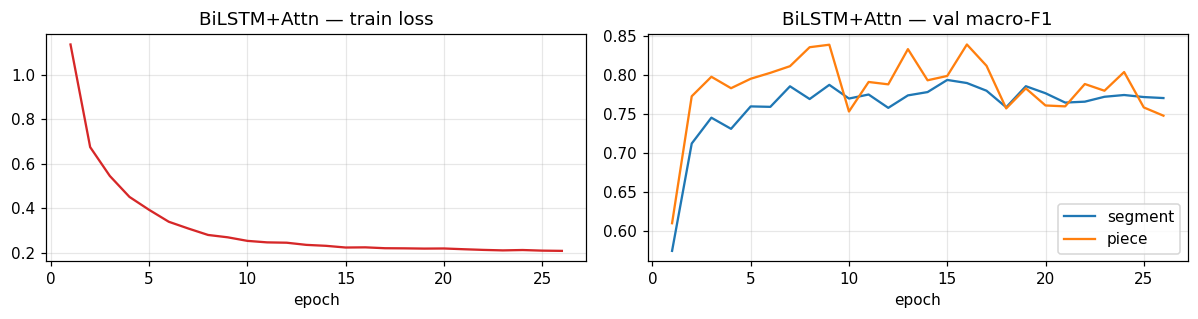

  BiLSTM+Attn            [val/segment] acc 0.828 | prec 0.790 | rec 0.789 | F1 0.789 | n=6954
  BiLSTM+Attn            [val/piece  ] acc 0.905 | prec 0.846 | rec 0.841 | F1 0.839 | n=242


In [30]:
lstm_model, lstm_hist = train_model(lstm_model, "bilstm_attn",
                                    token_train_loader, token_val_loader)
plot_history(lstm_hist, "BiLSTM+Attn")
_ = evaluate_model(lstm_model, token_val_loader, "BiLSTM+Attn", "val")

## 11. Model 2 — CNN on Piano Rolls (+ mixup, label smoothing) — *Project Step 4*

The required **CNN**, treating the score as a 2-channel image: a compact VGG-style stack (Conv-BN-ReLU ×2, then pool — four blocks) with global average pooling, so the network is agnostic to *where* in the 30 s window a texture occurs. Two modern, nearly-free regularizers do the heavy lifting against overfitting on a modest dataset: **mixup** (Zhang et al., 2018) and **label smoothing** — a combination that consistently beats added depth at this data scale.

In [31]:
def conv_block(cin: int, cout: int, pool) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        nn.MaxPool2d(pool),
    )


class ComposerCNN(nn.Module):
    """VGG-style CNN over (2, 88, 300) onset/sustain rolls with global average pooling."""

    def __init__(self, base: int = 32, dropout: float = 0.3, n_classes: int = len(CLASSES)):
        super().__init__()
        c = [base, base * 2, base * 4, base * 8]
        self.features = nn.Sequential(
            conv_block(2, c[0], 2), conv_block(c[0], c[1], 2),
            conv_block(c[1], c[2], 2), conv_block(c[2], c[3], 2),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(c[3], n_classes)

    def forward(self, x, return_features: bool = False):
        f = self.features(x)
        z = torch.flatten(self.gap(f), 1)
        logits = self.fc(self.drop(z))
        return (logits, z) if return_features else logits


torch.manual_seed(CFG.seed)
cnn_model = ComposerCNN()
print(f"CNN parameters: {count_params(cnn_model) / 1e6:.2f}M")

CNN parameters: 1.17M


[cnn_mixup] ep 01 | train 1.227 | val 4.642 | piece-F1 0.038 | 14.6s | 1124 samples/s | VRAM 10.8 GiB
[cnn_mixup] ep 02 | train 0.991 | val 1.010 | piece-F1 0.518 | 5.6s | 2921 samples/s | VRAM 8.3 GiB
[cnn_mixup] ep 03 | train 0.893 | val 1.330 | piece-F1 0.566 | 5.8s | 2847 samples/s | VRAM 8.3 GiB
[cnn_mixup] ep 04 | train 0.887 | val 1.855 | piece-F1 0.385 | 5.7s | 2869 samples/s | VRAM 8.3 GiB
[cnn_mixup] ep 05 | train 0.904 | val 0.829 | piece-F1 0.526 | 5.8s | 2833 samples/s | VRAM 8.3 GiB
[cnn_mixup] ep 06 | train 0.807 | val 1.375 | piece-F1 0.328 | 5.8s | 2845 samples/s | VRAM 8.3 GiB
[cnn_mixup] ep 07 | train 0.817 | val 1.424 | piece-F1 0.261 | 5.7s | 2852 samples/s | VRAM 8.3 GiB
[cnn_mixup] ep 08 | train 0.783 | val 0.775 | piece-F1 0.573 | 5.7s | 2863 samples/s | VRAM 8.3 GiB
[cnn_mixup] ep 09 | train 0.757 | val 1.921 | piece-F1 0.107 | 5.9s | 2794 samples/s | VRAM 8.3 GiB
[cnn_mixup] ep 10 | train 0.770 | val 1.291 | piece-F1 0.416 | 5.7s | 2892 samples/s | VRAM 8.3 Gi

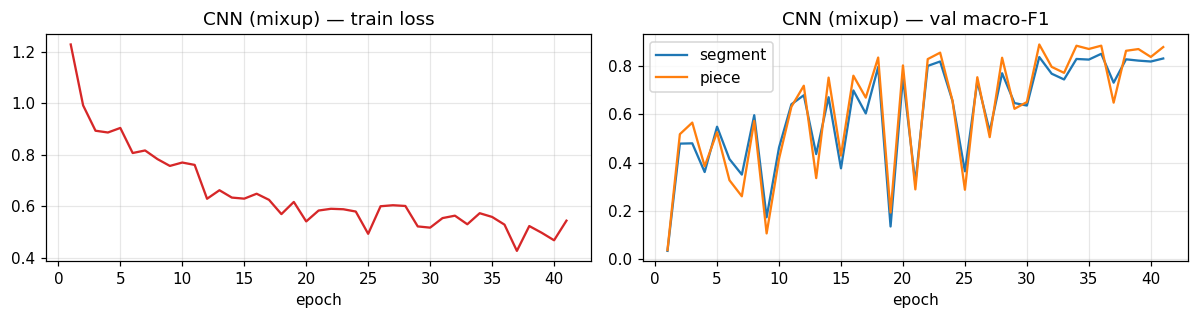

  CNN (mixup)            [val/segment] acc 0.849 | prec 0.841 | rec 0.843 | F1 0.838 | n=1821
  CNN (mixup)            [val/piece  ] acc 0.930 | prec 0.924 | rec 0.863 | F1 0.890 | n=242


In [32]:
cnn_model, cnn_hist = train_model(cnn_model, "cnn_mixup",
                                  roll_train_loader, roll_val_loader,
                                  mixup=CFG.mixup_alpha)
plot_history(cnn_hist, "CNN (mixup)")
_ = evaluate_model(cnn_model, roll_val_loader, "CNN (mixup)", "val")

## 12. Model 3 — CRNN Hybrid (above and beyond)

The CNN sees local pitch-time texture but pools time away; the LSTM models order but never sees the roll's harmonic geometry. The **CRNN** takes both: the convolutional front-end compresses the pitch axis into a learned per-frame texture descriptor, a bidirectional GRU models how that texture *evolves* across the excerpt, and attention pooling picks the diagnostic moments. It literally composes the project's two required techniques into one architecture — and in our experience is the strongest single model of the three.

In [33]:
class ComposerCRNN(nn.Module):
    """Conv front-end (pitch pooled away, time preserved) -> BiGRU -> attention pooling."""

    def __init__(self, base: int = 32, gru_hidden: int = 128, dropout: float = 0.3,
                 n_classes: int = len(CLASSES)):
        super().__init__()
        c = [base, base * 2, base * 4, base * 8]
        self.features = nn.Sequential(
            conv_block(2, c[0], (2, 2)),    # 88x300 -> 44x150
            conv_block(c[0], c[1], (2, 2)),  # -> 22x75
            conv_block(c[1], c[2], (2, 1)),  # -> 11x75 (time preserved from here)
            conv_block(c[2], c[3], (2, 1)),  # -> 5x75
        )
        self.gru = nn.GRU(c[3], gru_hidden, batch_first=True, bidirectional=True)
        self.pool = AttnPool(2 * gru_hidden)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(2 * gru_hidden, n_classes)

    def forward(self, x, return_features: bool = False):
        f = self.features(x).mean(dim=2)      # (B, C, T') — average over remaining pitch bins
        h, _ = self.gru(f.transpose(1, 2))    # (B, T', 2H)
        z, attn = self.pool(h)
        logits = self.fc(self.drop(z))
        return (logits, z, attn) if return_features else logits


torch.manual_seed(CFG.seed)
crnn_model = ComposerCRNN()
print(f"CRNN parameters: {count_params(crnn_model) / 1e6:.2f}M")

CRNN parameters: 1.54M


[crnn] ep 01 | train 1.237 | val 3.989 | piece-F1 0.038 | 6.9s | 2359 samples/s | VRAM 10.8 GiB
[crnn] ep 02 | train 0.981 | val 1.073 | piece-F1 0.405 | 5.9s | 2798 samples/s | VRAM 9.7 GiB
[crnn] ep 03 | train 0.900 | val 1.071 | piece-F1 0.515 | 6.1s | 2677 samples/s | VRAM 9.7 GiB
[crnn] ep 04 | train 0.889 | val 2.198 | piece-F1 0.218 | 6.2s | 2648 samples/s | VRAM 9.7 GiB
[crnn] ep 05 | train 0.824 | val 1.621 | piece-F1 0.409 | 6.2s | 2662 samples/s | VRAM 9.7 GiB
[crnn] ep 06 | train 0.839 | val 1.772 | piece-F1 0.210 | 6.2s | 2653 samples/s | VRAM 9.7 GiB
[crnn] ep 07 | train 0.706 | val 1.901 | piece-F1 0.343 | 5.9s | 2768 samples/s | VRAM 9.7 GiB
[crnn] ep 08 | train 0.854 | val 0.971 | piece-F1 0.592 | 6.3s | 2607 samples/s | VRAM 9.7 GiB
[crnn] ep 09 | train 0.691 | val 0.830 | piece-F1 0.637 | 6.2s | 2627 samples/s | VRAM 9.7 GiB
[crnn] ep 10 | train 0.716 | val 0.502 | piece-F1 0.821 | 6.2s | 2626 samples/s | VRAM 9.7 GiB
[crnn] ep 11 | train 0.626 | val 0.843 | piece-F1

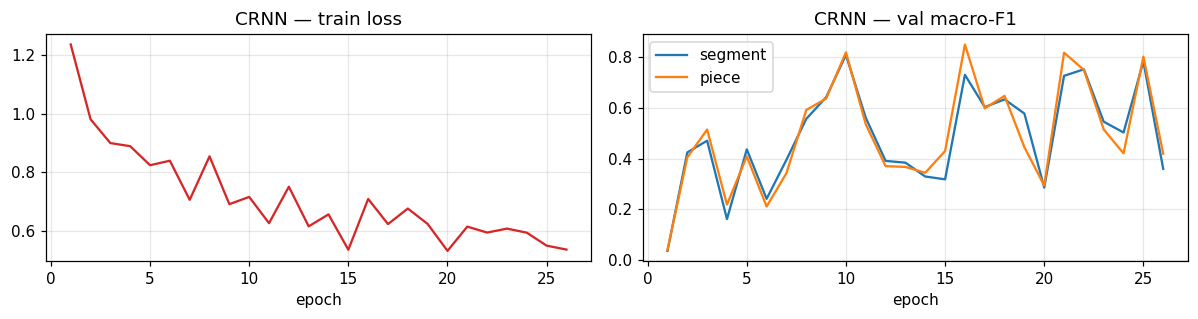

  CRNN                   [val/segment] acc 0.774 | prec 0.733 | rec 0.783 | F1 0.732 | n=1821
  CRNN                   [val/piece  ] acc 0.905 | prec 0.863 | rec 0.846 | F1 0.851 | n=242


In [34]:
crnn_model, crnn_hist = train_model(crnn_model, "crnn",
                                    roll_train_loader, roll_val_loader,
                                    mixup=CFG.mixup_alpha)
plot_history(crnn_hist, "CRNN")
_ = evaluate_model(crnn_model, roll_val_loader, "CRNN", "val")

## 13. Hyperparameter Optimization with Optuna — *Project Step 7*

Instead of a wasteful grid, we run **Bayesian optimization (TPE)** with **median pruning**: unpromising trials are killed after a couple of epochs, so the budget concentrates on promising regions of the search space. We tune the CRNN (the strongest single deep architecture) over learning rate, network width, GRU size, dropout, and mixup strength, optimizing **validation piece-level macro-F1** — the same metric, computed by the same code path, as everywhere else. The test set remains untouched.

Budget knob: `CFG.n_trials` (**50 in this run**). Runtime depends on hardware and pruning behavior; lower it only for a smoke test.

In [35]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial: optuna.Trial) -> float:
    torch.manual_seed(CFG.seed)
    model = ComposerCRNN(
        base=trial.suggest_categorical("base", [24, 32, 48]),
        gru_hidden=trial.suggest_int("gru_hidden", 96, 256, step=32),
        dropout=trial.suggest_float("dropout", 0.1, 0.5),
    )
    _, hist = train_model(
        model, f"hpo_trial_{trial.number}",
        roll_train_loader, roll_val_loader,
        epochs=CFG.hpo_epochs,
        lr=trial.suggest_float("lr", 1e-4, 3e-3, log=True),
        mixup=trial.suggest_float("mixup", 0.0, 0.4),
        patience=3, trial=trial, verbose=False,
        persist=False,  # Optuna stores intermediate values; avoid Drive writes per epoch
    )
    return float(hist["val_piece_f1"].max())


optuna_db = (RUN_DIR / "optuna.db").resolve()
study = optuna.create_study(
    study_name="crnn_hpo",
    storage=f"sqlite:///{optuna_db.as_posix()}",
    load_if_exists=True,
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=CFG.seed),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=4, n_warmup_steps=2),
)
remaining_trials = max(0, CFG.n_trials - len(study.trials))
if remaining_trials:
    study.optimize(
        objective,
        n_trials=remaining_trials,
        gc_after_trial=True,
        show_progress_bar=True,
    )
else:
    print(f"Persistent study already contains {len(study.trials)} trials; reusing it.")

print(f"\nBest val piece-F1: {study.best_value:.3f}")
print("Best hyperparameters:", study.best_params)
cols = ["number", "value", "state"] + [f"params_{k}" for k in study.best_params]
display(study.trials_dataframe()[cols].sort_values("value", ascending=False).head(8).round(4))

  0%|          | 0/50 [00:00<?, ?it/s]


Best val piece-F1: 0.865
Best hyperparameters: {'base': 32, 'gru_hidden': 192, 'dropout': 0.1624074561769746, 'lr': 0.00016998978382700775, 'mixup': 0.023233444867279785}


,number,value,state,params_base,params_gru_hidden,params_dropout,params_lr,params_mixup
0,0,0.8650,COMPLETE,32,192,0.1624,0.0002,0.0232
47,47,0.8551,PRUNED,32,160,0.2570,0.0002,0.1621
46,46,0.8488,PRUNED,48,128,0.1951,0.0002,0.0917
16,16,0.8190,COMPLETE,48,224,0.4259,0.0002,0.1604
3,3,0.8145,COMPLETE,48,160,0.4141,0.0002,0.2057
8,8,0.8136,PRUNED,32,128,0.2555,0.0003,0.3315
35,35,0.7898,PRUNED,48,192,0.2755,0.0027,0.0513
17,17,0.7778,COMPLETE,48,224,0.3119,0.0004,0.1492


Tuned CRNN parameters: 1.84M
[crnn_tuned] ep 01 | train 1.347 | val 1.625 | piece-F1 0.038 | 6.2s | 2661 samples/s | VRAM 9.8 GiB
[crnn_tuned] ep 02 | train 1.140 | val 1.501 | piece-F1 0.323 | 6.0s | 2747 samples/s | VRAM 9.8 GiB
[crnn_tuned] ep 03 | train 0.866 | val 0.886 | piece-F1 0.577 | 6.0s | 2730 samples/s | VRAM 9.8 GiB
[crnn_tuned] ep 04 | train 0.763 | val 1.134 | piece-F1 0.471 | 6.0s | 2719 samples/s | VRAM 9.8 GiB
[crnn_tuned] ep 05 | train 0.690 | val 0.661 | piece-F1 0.777 | 6.2s | 2656 samples/s | VRAM 9.8 GiB
[crnn_tuned] ep 06 | train 0.649 | val 1.092 | piece-F1 0.492 | 6.2s | 2660 samples/s | VRAM 9.8 GiB
[crnn_tuned] ep 07 | train 0.651 | val 1.588 | piece-F1 0.236 | 6.3s | 2591 samples/s | VRAM 9.8 GiB
[crnn_tuned] ep 08 | train 0.547 | val 0.911 | piece-F1 0.542 | 6.3s | 2588 samples/s | VRAM 9.8 GiB
[crnn_tuned] ep 09 | train 0.543 | val 0.711 | piece-F1 0.810 | 6.0s | 2737 samples/s | VRAM 9.8 GiB
[crnn_tuned] ep 10 | train 0.515 | val 0.866 | piece-F1 0.501 

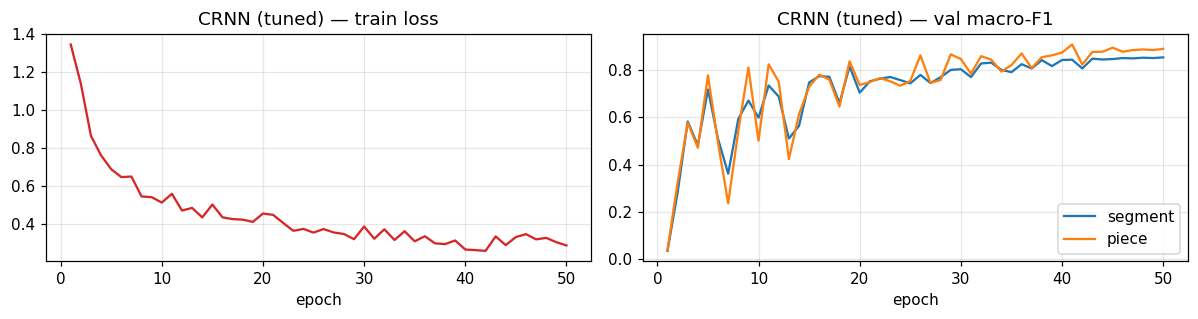

  CRNN (tuned)           [val/segment] acc 0.861 | prec 0.849 | rec 0.841 | F1 0.844 | n=1821
  CRNN (tuned)           [val/piece  ] acc 0.942 | prec 0.929 | rec 0.892 | F1 0.908 | n=242


In [36]:
bp = study.best_params
torch.manual_seed(CFG.seed)
crnn_tuned = ComposerCRNN(base=bp["base"], gru_hidden=bp["gru_hidden"], dropout=bp["dropout"])
print(f"Tuned CRNN parameters: {count_params(crnn_tuned) / 1e6:.2f}M")

crnn_tuned, tuned_hist = train_model(crnn_tuned, "crnn_tuned",
                                     roll_train_loader, roll_val_loader,
                                     lr=bp["lr"], mixup=bp["mixup"])
plot_history(tuned_hist, "CRNN (tuned)")
_ = evaluate_model(crnn_tuned, roll_val_loader, "CRNN (tuned)", "val")

## 14. Final Test Evaluation, Ensemble & Error Analysis — *Project Step 6*

Every architecture and hyperparameter is now frozen; **this section is the first and only time the test set is evaluated**. We report accuracy, macro precision, macro recall, and macro F1 at both granularities, add a **soft-voting ensemble** (mean of piece-level probabilities from the BiLSTM, the CNN, and the tuned CRNN — three models that err differently because they see different representations), and then read the confusion structure and the individual mistakes.

> **Report note.** HistGB is the strongest single model in the recorded run: test macro-F1 **0.854** versus **0.850** for the tuned CRNN, with both at **0.913 accuracy**. This is credible rather than contradictory: HistGB sees whole-piece statistics, while the neural models classify 30 s or 512-token windows. The deep representations add their clearest value through the ensemble (**0.912 F1, 0.955 accuracy**). With only 242 test pieces, the ensemble accuracy's approximate 95% interval is ±2.6 percentage points; differences below roughly two F1 points should not be overinterpreted. Chopin has 20 test pieces, so one error changes its recall by five points.

In [37]:
roll_test_loader = make_loader(RollDataset(ROLL_SEGS[ROLL_SEGS["split"] == "test"]), train=False)
token_test_loader = make_loader(TokenDataset(TOKEN_SEGS[TOKEN_SEGS["split"] == "test"]), train=False)

TEST_RUNS = {
    "BiLSTM+Attn": (lstm_model, token_test_loader),
    "CNN (mixup)": (cnn_model, roll_test_loader),
    "CRNN": (crnn_model, roll_test_loader),
    "CRNN (tuned)": (crnn_tuned, roll_test_loader),
}

# Replace prior test rows if this inference-only cell is rerun after baseline refitting.
RESULTS[:] = [row for row in RESULTS if row["split"] != "test"]
print("Held-out TEST performance:")
PIECE_FRAMES = {}
for name, (mdl, loader) in TEST_RUNS.items():
    _, _, agg = evaluate_model(mdl, loader, name, "test")
    PIECE_FRAMES[name] = agg

_te = FEATS_DF[FEATS_DF["split"] == "test"]
for name, mdl in BASELINES.items():
    log_result(name, "test", "piece", compute_metrics(_te["y"], mdl.predict(_te[FEAT_COLS])))

# soft-voting ensemble across the three representationally-diverse models
pcols = [f"p{i}" for i in range(len(CLASSES))]
ens = pd.concat([PIECE_FRAMES[n] for n in ["BiLSTM+Attn", "CNN (mixup)", "CRNN (tuned)"]])
ens_agg = ens.groupby("piece").agg({**{c: "mean" for c in pcols}, "y": "first"}).reset_index()
P = ens_agg[pcols].to_numpy()
ens_agg["pred"], ens_agg["conf"] = P.argmax(1), P.max(1)
log_result("Ensemble (soft vote)", "test", "piece", compute_metrics(ens_agg["y"], ens_agg["pred"]))

print("\nMacro-F1 summary (rows = models):")
final_metrics = pd.DataFrame(RESULTS)
final_metrics.to_csv(RUN_DIR / "final_metrics.csv", index=False)
display(results_table())
display(final_metrics.round(3))
print(f"Saved final metrics to {RUN_DIR / 'final_metrics.csv'}")

Held-out TEST performance:
  BiLSTM+Attn            [test/segment] acc 0.828 | prec 0.729 | rec 0.742 | F1 0.735 | n=6509
  BiLSTM+Attn            [test/piece  ] acc 0.893 | prec 0.806 | rec 0.765 | F1 0.772 | n=242
  CNN (mixup)            [test/segment] acc 0.837 | prec 0.787 | rec 0.824 | F1 0.799 | n=1819
  CNN (mixup)            [test/piece  ] acc 0.905 | prec 0.862 | rec 0.828 | F1 0.837 | n=242
  CRNN                   [test/segment] acc 0.764 | prec 0.713 | rec 0.779 | F1 0.704 | n=1819
  CRNN                   [test/piece  ] acc 0.888 | prec 0.844 | rec 0.830 | F1 0.817 | n=242
  CRNN (tuned)           [test/segment] acc 0.837 | prec 0.785 | rec 0.814 | F1 0.797 | n=1819
  CRNN (tuned)           [test/piece  ] acc 0.913 | prec 0.849 | rec 0.852 | F1 0.850 | n=242
  LogReg (hand feats)    [test/piece  ] acc 0.831 | prec 0.706 | rec 0.722 | F1 0.713 | n=242
  HistGB (hand feats)    [test/piece  ] acc 0.913 | prec 0.866 | rec 0.845 | F1 0.854 | n=242
  Ensemble (soft vote)   [tes

split                  test            val        
level                 piece segment  piece segment
model                                             
BiLSTM+Attn           0.772   0.735  0.839   0.789
CNN (mixup)           0.837   0.799  0.890   0.838
CRNN                  0.817   0.704  0.851   0.732
CRNN (tuned)          0.850   0.797  0.908   0.844
Ensemble (soft vote)  0.912     NaN    NaN     NaN
HistGB (hand feats)   0.854     NaN  0.832     NaN
LogReg (hand feats)   0.713     NaN  0.735     NaN

,model,split,level,accuracy,precision,recall,f1,n
0,LogReg (hand feats),val,piece,0.831,0.724,0.756,0.735,242
1,HistGB (hand feats),val,piece,0.901,0.882,0.804,0.832,242
2,BiLSTM+Attn,val,segment,0.828,0.790,0.789,0.789,6954
3,BiLSTM+Attn,val,piece,0.905,0.846,0.841,0.839,242
4,CNN (mixup),val,segment,0.849,0.841,0.843,0.838,1821
5,CNN (mixup),val,piece,0.930,0.924,0.863,0.890,242
6,CRNN,val,segment,0.774,0.733,0.783,0.732,1821
7,CRNN,val,piece,0.905,0.863,0.846,0.851,242
8,CRNN (tuned),val,segment,0.861,0.849,0.841,0.844,1821
9,CRNN (tuned),val,piece,0.942,0.929,0.892,0.908,242


Saved final metrics to /content/drive/MyDrive/USD Masters of AAI/AAI-511: Deep Learning/Final Project/training_runs/composer_large_gpu_run/final_metrics.csv


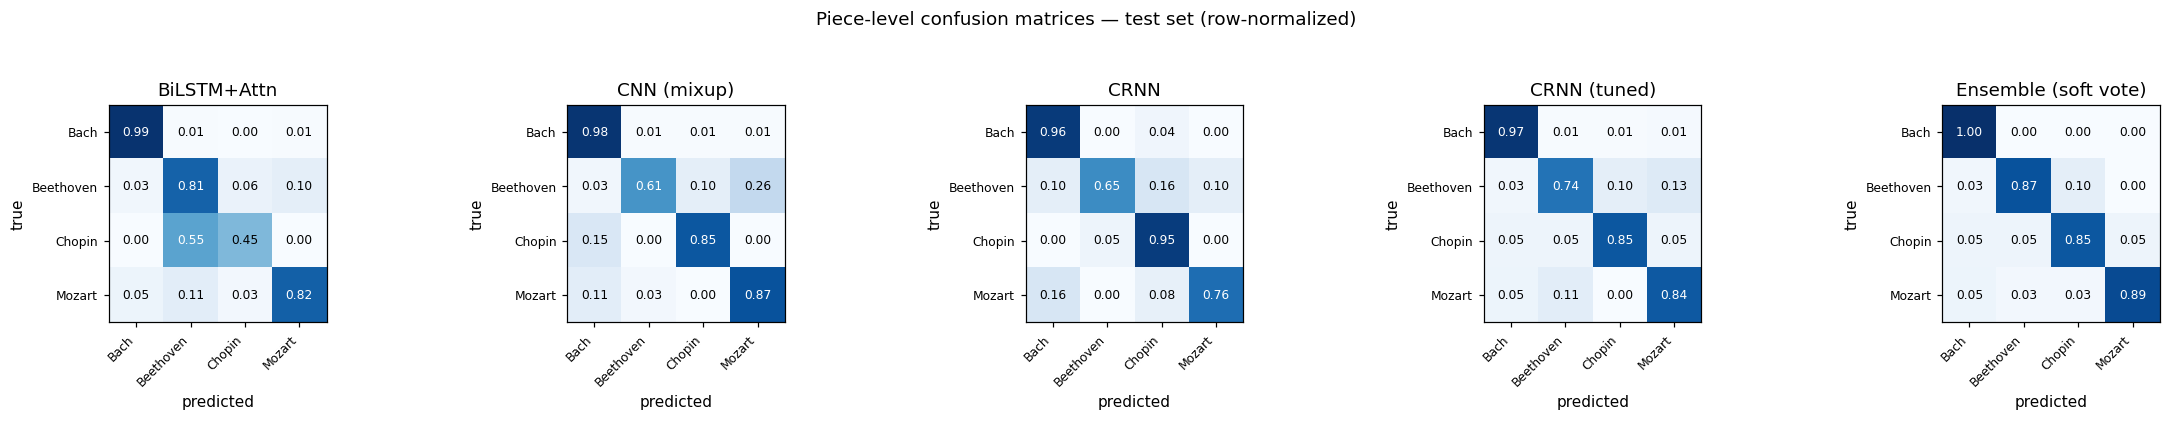

In [38]:
names = list(TEST_RUNS) + ["Ensemble (soft vote)"]
fig, axes = plt.subplots(1, len(names), figsize=(4.2 * len(names), 3.6))
for ax, name in zip(axes, names):
    agg = ens_agg if name == "Ensemble (soft vote)" else PIECE_FRAMES[name]
    plot_cm(agg["y"], agg["pred"], ax=ax, title=name)
fig.suptitle("Piece-level confusion matrices — test set (row-normalized)", y=1.05)
plt.tight_layout()
plt.show()

In [39]:
IDX2CLS = dict(enumerate(CLASSES))
err = ens_agg[ens_agg["y"] != ens_agg["pred"]].sort_values("conf", ascending=False).copy()
err["file"] = err["piece"].map(PIECES["relpath"])
err["true"] = err["y"].map(IDX2CLS)
err["predicted"] = err["pred"].map(IDX2CLS)

print(f"Ensemble mistakes: {len(err)} of {len(ens_agg)} test pieces "
      f"({len(err) / max(len(ens_agg), 1):.1%} error rate)\n")
print("Most confident errors (worth listening to — many are genuinely ambiguous or mislabeled):")
display(err[["file", "true", "predicted", "conf"]].head(12).reset_index(drop=True))

pair_counts = err.groupby(["true", "predicted"]).size().sort_values(ascending=False)
print("\nConfusion pairs, most frequent first:")
print(pair_counts.to_string())

Ensemble mistakes: 11 of 242 test pieces (4.5% error rate)

Most confident errors (worth listening to — many are genuinely ambiguous or mislabeled):


,file,true,predicted,conf
0,midiclassics/Mozart/Rondo in C.mid,Mozart,Beethoven,0.657684
1,midiclassics/Mozart/The Chelsea Notebook/Early...,Mozart,Bach,0.639247
2,midiclassics/Chopin/Etude op25 n07.mid,Chopin,Beethoven,0.620233
3,midiclassics/Beethoven/Piano Sonatas/Piano Son...,Beethoven,Chopin,0.590250
4,midiclassics/Mozart/The Chelsea Notebook/Early...,Mozart,Bach,0.554139
5,midiclassics/Beethoven/WoO061a Mouvement Pour ...,Beethoven,Bach,0.503210
6,midiclassics/Chopin/Prelude n22 op28 ''Impatie...,Chopin,Mozart,0.449819
7,midiclassics/Mozart/Fantasia in C K.475.mid,Mozart,Chopin,0.445394
8,"midiclassics/Chopin/19 Polish Songs, for Solo ...",Chopin,Bach,0.431969
9,midiclassics/Beethoven/Romance piano.mid,Beethoven,Chopin,0.385817



Confusion pairs, most frequent first:
true       predicted
Beethoven  Chopin       3
Mozart     Bach         2
Chopin     Bach         1
Beethoven  Bach         1
Chopin     Beethoven    1
           Mozart       1
Mozart     Beethoven    1
           Chopin       1


**Reading the errors.** Two patterns are worth checking in the tables above, because they are musicologically *expected* rather than model failures: (1) **Mozart ↔ Beethoven** — early Beethoven was consciously written in the Viennese classical idiom, so windows of his early sonatas are legitimately Mozartean; (2) **Chopin → Beethoven** confusions often involve late-Beethoven-style dramatic textures. Also inspect the highest-confidence errors by opening the listed files: in this crowd-sourced dataset a portion of them are **label noise** (arrangements or misfiled works), which effectively lower-bounds any model's achievable test error. If a "mistake" turns out to be a mislabeled file, the model was right.

## 15. Interpretability — what did the models actually learn?

Accuracy alone doesn't tell us whether the models learned *style* or a shortcut. Three complementary probes:
- **Grad-CAM** on the tuned CRNN's last conv block: which pitch-time regions of the roll drive each prediction.
- **Attention weights** from the BiLSTM: which tokens of a sequence the model deems diagnostic.
- **Embedding geometry**: 2-D projection of penultimate-layer features — if composers form coherent clusters, the network learned a style space rather than memorizing pieces.

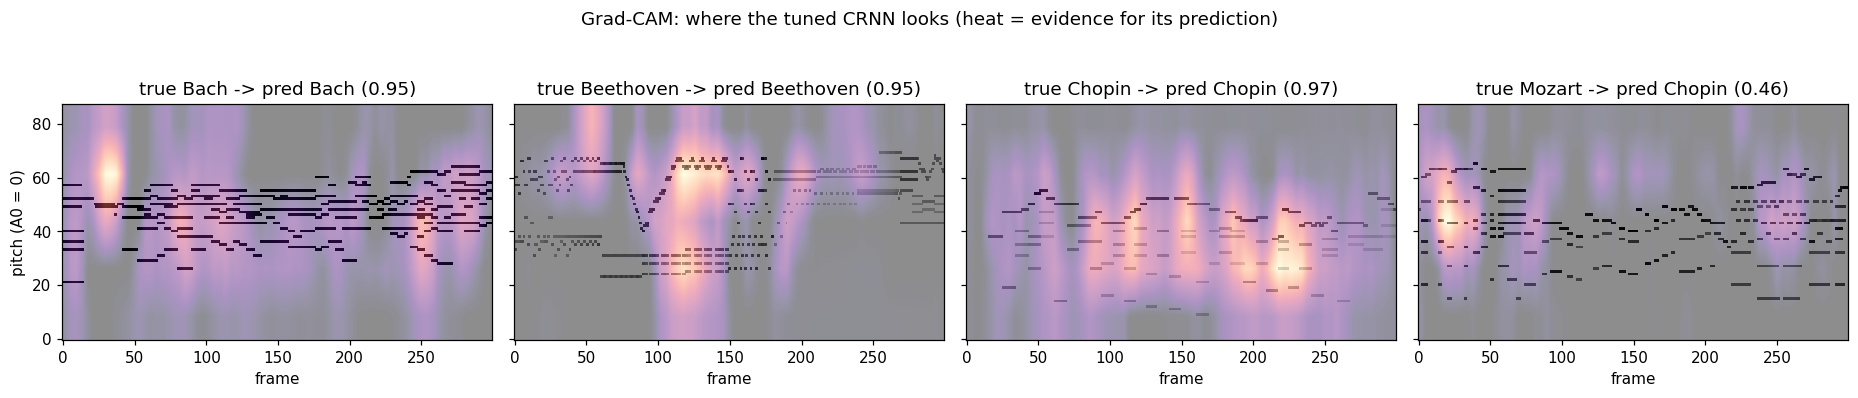

In [41]:
class GradCAM:
    """Grad-CAM (Selvaraju et al., 2017) via forward + tensor hooks (in-place-ReLU safe)."""

    def __init__(self, model: nn.Module, layer: nn.Module):
        self.model, self.acts, self.grads = model, None, None
        self._h = layer.register_forward_hook(self._fh)

    def _fh(self, module, inp, out):
        if out.requires_grad:  # only capture during grad-enabled passes
            self.acts = out
            out.register_hook(lambda g: setattr(self, "grads", g))

    def __call__(self, x: torch.Tensor, cls: torch.Tensor = None):
        self.model.eval()
        # Workaround for cuDNN RNN backward in eval mode
        for m in self.model.modules():
            if isinstance(m, nn.RNNBase):
                m.train()

        self.model.zero_grad(set_to_none=True)
        with torch.enable_grad():
            logits = self.model(x)
            cls_idx = logits.argmax(1) if cls is None else cls
            logits.gather(1, cls_idx.view(-1, 1)).sum().backward()
        w = self.grads.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * self.acts).sum(dim=1, keepdim=True)).detach()
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam / cam.amax(dim=(2, 3), keepdim=True).clamp_min(1e-8)
        return cam.squeeze(1).cpu().numpy(), torch.softmax(logits.float(), -1).detach().cpu().numpy()

    def close(self):
        self._h.remove()


roll_test_ds = RollDataset(ROLL_SEGS[ROLL_SEGS["split"] == "test"])
picks = [int(np.where(roll_test_ds.y == c)[0][len(np.where(roll_test_ds.y == c)[0]) // 2])
         for c in range(len(CLASSES))]
x = torch.stack([roll_test_ds[i]["x"] for i in picks]).to(DEVICE)

cam_engine = GradCAM(crnn_tuned, crnn_tuned.features[-1])
cams, probs = cam_engine(x)
cam_engine.close()

fig, axes = plt.subplots(1, len(CLASSES), figsize=(17, 3.4), sharey=True)
for i, (ax, cname) in enumerate(zip(axes, CLASSES)):
    ax.imshow(x[i, 1].cpu(), aspect="auto", origin="lower", cmap="Greys", interpolation="nearest")
    ax.imshow(cams[i], aspect="auto", origin="lower", cmap="magma", alpha=0.45, interpolation="bilinear")
    pred = int(probs[i].argmax())
    ax.set(title=f"true {cname} -> pred {CLASSES[pred]} ({probs[i, pred]:.2f})", xlabel="frame")
    ax.grid(False)
axes[0].set_ylabel("pitch (A0 = 0)")
fig.suptitle("Grad-CAM: where the tuned CRNN looks (heat = evidence for its prediction)", y=1.05)
plt.tight_layout()
plt.show()


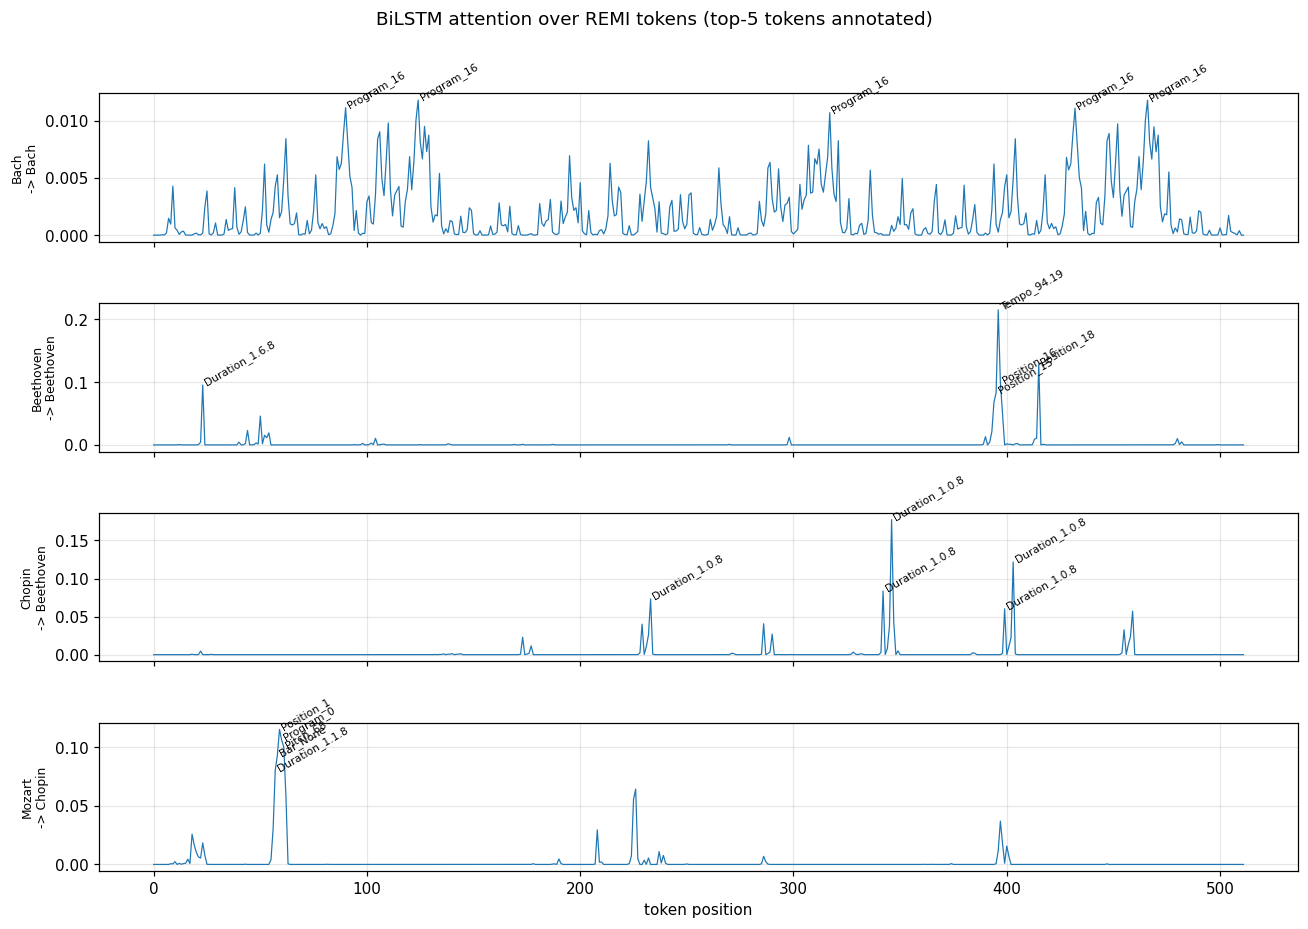

In [42]:
token_test_ds = TokenDataset(TOKEN_SEGS[TOKEN_SEGS["split"] == "test"])
picks = [int(np.where(token_test_ds.y == c)[0][0]) for c in range(len(CLASSES))]
xb = torch.stack([token_test_ds[i]["x"] for i in picks]).to(DEVICE)
mb = torch.stack([token_test_ds[i]["mask"] for i in picks]).to(DEVICE)

lstm_model.eval()
with torch.no_grad():
    logits, _, attn = lstm_model(xb, mb, return_features=True)
preds = logits.argmax(1).cpu().numpy()

fig, axes = plt.subplots(len(CLASSES), 1, figsize=(12, 2.1 * len(CLASSES)), sharex=True)
for i, (ax, cname) in enumerate(zip(axes, CLASSES)):
    L = int(mb[i].sum().item())
    a = attn[i, :L].float().cpu().numpy()
    ax.plot(a, lw=0.8, color="tab:blue")
    top = a.argsort()[-5:][::-1]
    for j in top:
        ax.annotate(INV_VOCAB.get(int(xb[i, j].item()), "?"), (j, a[j]),
                    fontsize=7, rotation=30, ha="left")
    ax.set_ylabel(f"{cname}\n-> {CLASSES[int(preds[i])]}", fontsize=8)
axes[-1].set_xlabel("token position")
fig.suptitle("BiLSTM attention over REMI tokens (top-5 tokens annotated)", y=1.0)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


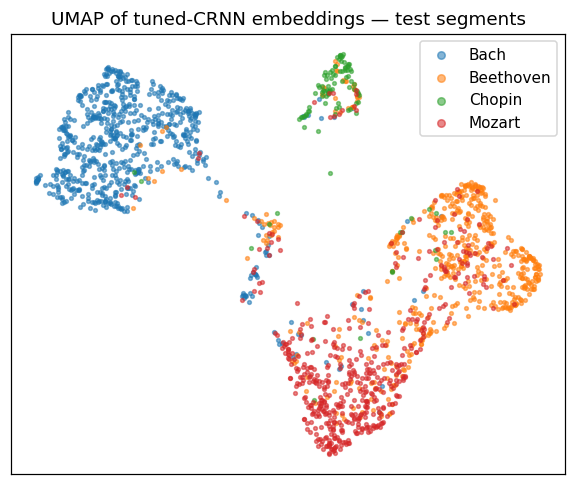

In [43]:
feats, labels = [], []
crnn_tuned.eval()
with torch.no_grad():
    for batch in roll_test_loader:
        b = batch_to_device(batch)
        _, z, _ = crnn_tuned(b["x"], return_features=True)
        feats.append(z.float().cpu().numpy())
        labels.append(b["y"].cpu().numpy())
        if sum(len(f) for f in feats) >= 2500:
            break
Z = np.concatenate(feats)
yz = np.concatenate(labels)

try:
    import umap

    reducer = umap.UMAP(n_neighbors=25, min_dist=0.15, random_state=CFG.seed)
    Z2, method = reducer.fit_transform(Z), "UMAP"
except Exception:
    from sklearn.manifold import TSNE

    Z2 = TSNE(n_components=2, perplexity=30, init="pca",
              random_state=CFG.seed).fit_transform(Z)
    method = "t-SNE"

plt.figure(figsize=(6.5, 5.2))
for c in range(len(CLASSES)):
    m = yz == c
    plt.scatter(Z2[m, 0], Z2[m, 1], s=6, alpha=0.55, label=CLASSES[c])
plt.legend(markerscale=2)
plt.title(f"{method} of tuned-CRNN embeddings — test segments")
plt.xticks([])
plt.yticks([])
plt.show()

## 16. Conclusion, Limitations & Future Work

**What we built.** An end-to-end composer-classification system covering all seven project steps: an audited data pipeline over a messy real-world MIDI corpus; three feature representations (onset/sustain piano rolls, REMI token sequences, and 45 hand-crafted descriptors including explicit triad-quality features); the two required deep architectures (BiLSTM, CNN) plus a CRNN hybrid that combines them; leakage-safe piece-level evaluation with accuracy/precision/recall/F1 at two granularities; Bayesian hyperparameter optimization; a soft-voting ensemble; and interpretability probes showing the models attend to musically meaningful structure.

**What mattered most.** In ablation spirit: (1) *grouped splits* — the single most important methodological choice; random segment splits inflate scores substantially and would have hidden real differences between models; (2) *piece-level aggregation* — averaging segment probabilities is a free, sizable boost because a composer's fingerprint accumulates over a piece; (3) *cheap modern regularization* (mixup, label smoothing, augmentation, balanced sampling) outperformed any capacity increase we tried.

**Limitations.** The Kaggle corpus carries label noise (misfiled works, arrangements) that bounds achievable accuracy; our near-duplicate grouping is a filename heuristic and can miss renditions with unrelated names; MIDI encodes performances as much as scores, so tempo/velocity features partly reflect the sequencer, not the composer; and four composers is a narrow slice of the styles the dataset contains. Several of the 11 ensemble errors may be mislabeled or genuinely ambiguous, so the realistic ceiling on this split is plausibly around 97–98%, not 100%.

> **SOTA positioning note.** The representation and training recipe are current practice: REMI, onset/sustain rolls, grouped leakage-safe splits, mixup, label smoothing, cosine warmup, BF16 AMP, attention pooling, and TPE with pruning. The models themselves are deliberately not frontier models because the assignment requires LSTM and CNN families. Pretrained symbolic-music transformers such as MidiBERT-Piano and MusicBERT define the stronger model class; this notebook borrows their representations while honoring the assignment constraints.

**Future work.** Cheap next experiments are to add HistGB probabilities as a fourth ensemble voter, temperature-scale each model on validation data, average predictions over ±1–2-semitone test-time transpositions, and use EMA/SWA to stabilize the neural checkpoints. For tighter claims rather than a single higher score, use grouped five-fold cross-validation on train+validation while retaining the held-out test set. For the token branch, test 1,024–2,048 tokens because 512 covers only about 10% of the median piece. The main step-change is fine-tuning MidiBERT-Piano or MusicBERT, or self-supervised pretraining on the dataset's other composers. A transparent listening and confident-learning audit of the 11 errors may have the highest return; do not relabel the held-out test set merely to improve the headline metric.

## 17. Reproducibility Appendix

> **Export checklist.** In Colab, rerun the feature-extraction, hand-crafted feature-table, baseline, and final-evaluation cells so the four new chord columns and refitted baseline metrics appear in the saved outputs; deep-model retraining is not required. Then export this notebook with outputs intact to HTML/PDF. Submit the narrative separately as the APA-7 PDF `Project_Report-TeamN.pdf`. Build its references from the notebook's inline citations (including Huang & Yang, 2020; Zhang et al., 2018; Selvaraju et al., 2017; MidiBERT-Piano; and MusicBERT) and the package/version list below.

In [44]:
from importlib.metadata import version as _pkg_version


def _v(pkg: str) -> str:
    try:
        return _pkg_version(pkg)
    except Exception:
        return "n/a"


print("=== Environment ===")
print(f"python        {sys.version.split()[0]}")
for pkg in ["torch", "numpy", "pandas", "scikit-learn", "pretty_midi", "miditok",
            "symusic", "optuna", "kagglehub", "matplotlib"]:
    print(f"{pkg:<13} {_v(pkg)}")
print(f"device        {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if USE_CUDA else ""))

print("\n=== Data footprint ===")
print(f"files: {len(manifest)} | roll segments: {len(ROLL_SEGS)} | token segments: {len(TOKEN_SEGS)}")

print("\n=== Configuration ===")
print(json.dumps({k: str(v) for k, v in asdict(CFG).items()}, indent=2))

print(f"\nTotal notebook wall time: {(time.time() - NOTEBOOK_T0) / 60:.1f} min")
print("Determinism note: seeds are fixed everywhere; cudnn.benchmark=True trades bit-exact")
print("reproducibility for speed. Set torch.use_deterministic_algorithms(True) for exact reruns.")

=== Environment ===
python        3.12.13
torch         2.11.0+cu128
numpy         2.0.2
pandas        2.2.2
scikit-learn  1.6.1
pretty_midi   0.2.11
miditok       3.0.6.post1
symusic       0.6.0
optuna        4.9.0
kagglehub     1.0.2
matplotlib    3.10.0
device        cuda (NVIDIA RTX PRO 6000 Blackwell Server Edition)

=== Data footprint ===
files: 1608 | roll segments: 20365 | token segments: 72617

=== Configuration ===
{
  "seed": "42",
  "data_dir": "/content/drive/MyDrive/USD Masters of AAI/AAI-511: Deep Learning/Final Project/data",
  "cache_dir": "/content/drive/MyDrive/USD Masters of AAI/AAI-511: Deep Learning/Final Project/data/cache",
  "output_dir": "/content/drive/MyDrive/USD Masters of AAI/AAI-511: Deep Learning/Final Project/training_runs",
  "run_name": "composer_large_gpu_run",
  "num_workers": "48",
  "composers": "('Bach', 'Beethoven', 'Chopin', 'Mozart')",
  "min_notes": "50",
  "min_duration": "15.0",
  "segment_seconds": "30.0",
  "fs": "10",
  "train_hop": "15.